In [52]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import jarque_bera, skew, kurtosis
import numexpr as ne
import numba
from numba import jit, prange
import joblib
from joblib import Parallel, delayed
import os
import time

# --- display config ---
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# --- global constants (from paper) ---
SIGMA_TAR  = 0.12       # annualized target volatility (12%), paper Section 4.2
RPM_WINDOW = 126        # 126 trading day lookback for partial moments, eq. (4)(5)
SCALE      = 21 / 126   # converts daily-sum to monthly variance units
FORM_START = 12         # formation period: t-12
FORM_END   = 2          # formation period: t-2  (skip t-1 to avoid reversal)
MAX_LEV    = 2.0        # 200% leverage cap for PMMC, paper Section 4.2
CACHE_DIR  = r'C:\Users\User\Documents\pmm\cache'
os.makedirs(CACHE_DIR, exist_ok=True)

print(f"numpy      : {np.__version__}")
print(f"pandas     : {pd.__version__}")
print(f"numba      : {numba.__version__}")
print(f"numexpr    : {ne.__version__}")
print(f"joblib     : {joblib.__version__}")
print(f"numexpr threads : {ne.detect_number_of_cores()} cores detected")
print(f"numba threads   : {numba.get_num_threads()} threads")
print()
print("--- Strategy constants ---")
print(f"  SIGMA_TAR  = {SIGMA_TAR}  (12% annualized target vol)")
print(f"  RPM_WINDOW = {RPM_WINDOW} trading days (~6 months)")
print(f"  SCALE      = {SCALE:.6f}  (21/126 monthly scaler, eq.4-5)")
print(f"  FORM       = t-{FORM_START} to t-{FORM_END}  (11-month formation, skip t-1)")
print(f"  MAX_LEV    = {MAX_LEV}  (200% cap for PMMC)")
print(f"  CACHE_DIR  = {CACHE_DIR}")


numpy      : 2.3.5
pandas     : 2.3.3
numba      : 0.62.1
numexpr    : 2.14.1
joblib     : 1.5.2
numexpr threads : 16 cores detected
numba threads   : 16 threads

--- Strategy constants ---
  SIGMA_TAR  = 0.12  (12% annualized target vol)
  RPM_WINDOW = 126 trading days (~6 months)
  SCALE      = 0.166667  (21/126 monthly scaler, eq.4-5)
  FORM       = t-12 to t-2  (11-month formation, skip t-1)
  MAX_LEV    = 2.0  (200% cap for PMMC)
  CACHE_DIR  = C:\Users\User\Documents\pmm\cache


In [53]:

# =============================================================================
# CELL 2 — Data Download
# All data from Kenneth R. French Data Library via pandas_datareader.
# We cache to parquet so we never re-download unless forced.
#
# Datasets:
#   mom10_monthly : 10 momentum decile portfolios (monthly %) — winners/losers
#   ff_daily      : Fama-French daily factors — we need Mkt-RF + RF for RPM
#   ff_monthly    : Fama-French monthly factors — RF, MKT, SMB, HML
#   ff5_monthly   : FF 5-factor monthly — adds RMW, CMA for spanning tests
# =============================================================================

def _cache_path(name):
    return os.path.join(CACHE_DIR, f"{name}.parquet")

def download_or_load(name, reader_fn):
    """Load from parquet cache if exists, else download and cache."""
    path = _cache_path(name)
    if os.path.exists(path):
        print(f"  [cache] {name}")
        return pd.read_parquet(path)
    print(f"  [download] {name} ...")
    t0 = time.time()
    df = reader_fn()
    df.to_parquet(path)
    print(f"           done in {time.time()-t0:.1f}s, shape={df.shape}")
    return df

# --- 10 momentum decile portfolios (monthly, value-weighted) ---
# P1 = losers (worst prior 12-2 return), P10 = winners
# French library name: '10_Portfolios_Prior_12_2'
mom10_monthly = download_or_load(
    'mom10_monthly',
    lambda: web.DataReader('10_Portfolios_Prior_12_2', 'famafrench', start='1926-01-01')[0]
)

# --- Fama-French daily factors: gives us Mkt-RF and RF at daily frequency ---
# Used to compute RPM+ and RPM- (need daily market returns, eq. 4 & 5)
ff_daily = download_or_load(
    'ff_daily',
    lambda: web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench', start='1926-01-01')[0]
)

# --- Fama-French 3-factor monthly: MKT-RF, SMB, HML, RF ---
ff_monthly = download_or_load(
    'ff_monthly',
    lambda: web.DataReader('F-F_Research_Data_Factors', 'famafrench', start='1926-01-01')[0]
)

# --- FF 5-factor monthly: adds RMW, CMA ---
ff5_monthly = download_or_load(
    'ff5_monthly',
    lambda: web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench', start='1963-01-01')[0]
)

# --- sample window: paper starts 1927-07; end = latest month in French cache ---
SAMPLE_START = pd.Period('1927-07', freq='M')
SAMPLE_END = min(mom10_monthly.index.max(), ff_monthly.index.max(), ff5_monthly.index.max())
DAILY_END = SAMPLE_END.to_timestamp(how='end').strftime('%Y-%m-%d')
PAPER_END = pd.Period('2018-12', freq='M')  # original paper (comparison only)
print(f'Sample window: {SAMPLE_START} -> {SAMPLE_END}  (paper ended {PAPER_END})')


print()
print("=== Data shapes and date ranges ===")
for name, df in [('mom10_monthly', mom10_monthly),
                 ('ff_daily',      ff_daily),
                 ('ff_monthly',    ff_monthly),
                 ('ff5_monthly',   ff5_monthly)]:
    print(f"  {name:20s} shape={str(df.shape):15s} "
          f"index={df.index[0]} -> {df.index[-1]}  dtype={df.index.dtype}")

print()
print("=== mom10_monthly columns (decile portfolios) ===")
print(list(mom10_monthly.columns))
print()
print("=== ff_daily columns ===")
print(list(ff_daily.columns))
print()
print("=== ff_monthly columns ===")
print(list(ff_monthly.columns))


  [cache] mom10_monthly
  [cache] ff_daily
  [cache] ff_monthly
  [cache] ff5_monthly
Sample window: 1927-07 -> 2026-02  (paper ended 2018-12)

=== Data shapes and date ranges ===
  mom10_monthly        shape=(1190, 10)      index=1927-01 -> 2026-02  dtype=period[M]
  ff_daily             shape=(26190, 4)      index=1926-07-01 00:00:00 -> 2026-02-27 00:00:00  dtype=datetime64[ns]
  ff_monthly           shape=(1196, 4)       index=1926-07 -> 2026-02  dtype=period[M]
  ff5_monthly          shape=(752, 6)        index=1963-07 -> 2026-02  dtype=period[M]

=== mom10_monthly columns (decile portfolios) ===
['Lo PRIOR', 'PRIOR 2', 'PRIOR 3', 'PRIOR 4', 'PRIOR 5', 'PRIOR 6', 'PRIOR 7', 'PRIOR 8', 'PRIOR 9', 'Hi PRIOR']

=== ff_daily columns ===
['Mkt-RF', 'SMB', 'HML', 'RF']

=== ff_monthly columns ===
['Mkt-RF', 'SMB', 'HML', 'RF']


In [54]:

# =============================================================================
# CELL: Logger utility
# Writes a compact state log after each cell so we can look up variable
# shapes/dtypes/ranges without loading data into memory.
# Log file: C:\Users\User\Documents\pmm\cell_state_log.md
# Usage in each cell (last line):
#   log_state("Cell N — description", {...})
# =============================================================================

import json
from datetime import datetime

LOG_PATH = r'C:\Users\User\Documents\pmm\cell_state_log.md'

def _fmt(val):
    """Convert a value to a concise loggable string."""
    if isinstance(val, pd.DataFrame):
        idx = val.index
        idx_info = f"{idx[0]} -> {idx[-1]}" if len(idx) > 0 else "empty"
        return {
            "type"    : "DataFrame",
            "shape"   : list(val.shape),
            "columns" : list(val.columns),
            "dtypes"  : {c: str(val[c].dtype) for c in val.columns},
            "index"   : str(idx.dtype),
            "range"   : idx_info,
            "nulls"   : int(val.isnull().sum().sum()),
        }
    elif isinstance(val, pd.Series):
        idx = val.index
        idx_info = f"{idx[0]} -> {idx[-1]}" if len(idx) > 0 else "empty"
        return {
            "type"  : "Series",
            "len"   : len(val),
            "dtype" : str(val.dtype),
            "range" : idx_info,
            "nulls" : int(val.isnull().sum()),
            "min"   : float(val.min()) if pd.api.types.is_numeric_dtype(val) else None,
            "max"   : float(val.max()) if pd.api.types.is_numeric_dtype(val) else None,
        }
    elif isinstance(val, np.ndarray):
        return {
            "type"  : "ndarray",
            "shape" : list(val.shape),
            "dtype" : str(val.dtype),
            "min"   : float(val.min()),
            "max"   : float(val.max()),
        }
    elif isinstance(val, dict):
        return {k: _fmt(v) for k, v in val.items()}
    else:
        return str(val)

def log_state(cell_label, state_dict):
    """
    Append a cell's state snapshot to the log file.
    cell_label : str  e.g. "Cell 2 — Data Download"
    state_dict : dict of variable_name -> variable (any type)
    """
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    lines = [f"\n## {cell_label}  [{ts}]\n```json"]
    formatted = {k: _fmt(v) for k, v in state_dict.items()}
    lines.append(json.dumps(formatted, indent=2))
    lines.append("```\n")
    entry = "\n".join(lines)

    with open(LOG_PATH, 'a', encoding='utf-8') as f:
        f.write(entry)

    print(f"[log] state written -> {LOG_PATH}  ({cell_label})")

# Initialize log file with header if it doesn't exist
if not os.path.exists(LOG_PATH):
    with open(LOG_PATH, 'w', encoding='utf-8') as f:
        f.write("# PMM Notebook — Cell State Log\n")
        f.write("Each cell appends its key variable shapes/dtypes/ranges here.\n")
        f.write("Never load this whole file — grep or extract specific sections.\n\n")
    print(f"[log] created {LOG_PATH}")
else:
    print(f"[log] log file exists: {LOG_PATH}")

# --- now log cell 2 state (backfill since logger didn't exist then) ---
log_state("Cell 2 — Data Download", {
    "mom10_monthly" : mom10_monthly,
    "ff_daily"      : ff_daily,
    "ff_monthly"    : ff_monthly,
    "ff5_monthly"   : ff5_monthly,
})


[log] log file exists: C:\Users\User\Documents\pmm\cell_state_log.md
[log] state written -> C:\Users\User\Documents\pmm\cell_state_log.md  (Cell 2 — Data Download)


Sample window : 1927-07 -> 2026-02
Months        : 1184
Columns       : ['Lo PRIOR', 'PRIOR 2', 'PRIOR 3', 'PRIOR 4', 'PRIOR 5', 'PRIOR 6', 'PRIOR 7', 'PRIOR 8', 'PRIOR 9', 'Hi PRIOR']
NaN count     : 0

=== Raw WML (Hi PRIOR - Lo PRIOR) ===
  Mean monthly return : 1.1119%
  Annualized return   : 13.34%   (paper Table 1: 14.98%)
  Annualized vol      : 27.43%
  Annualized SR       : 0.4865    (paper Table 1: 0.52)
  Skewness            : -2.1915  (paper: -2.33)
  Excess kurtosis     : 15.9462  (paper: 17.48)

=== Sample values (confirm % not decimal) ===
         Lo PRIOR  Hi PRIOR
Date                       
1927-07  4.1100   13.3300  
1927-08 -0.5400    5.4800  
1927-09 -0.3900    7.2900  
1927-10 -6.0600   -6.0400  
1927-11 13.6400    6.2100  

=== 10 worst WML months (crash exposure) ===
  1932-08  -78.04%
  1932-07  -63.04%
  2009-04  -45.32%
  1939-09  -44.36%
  2001-01  -41.71%
  2009-03  -39.18%
  1938-06  -33.47%
  2020-04  -31.69%
  1933-04  -31.53%
  1933-05  -30.62%

=== 10

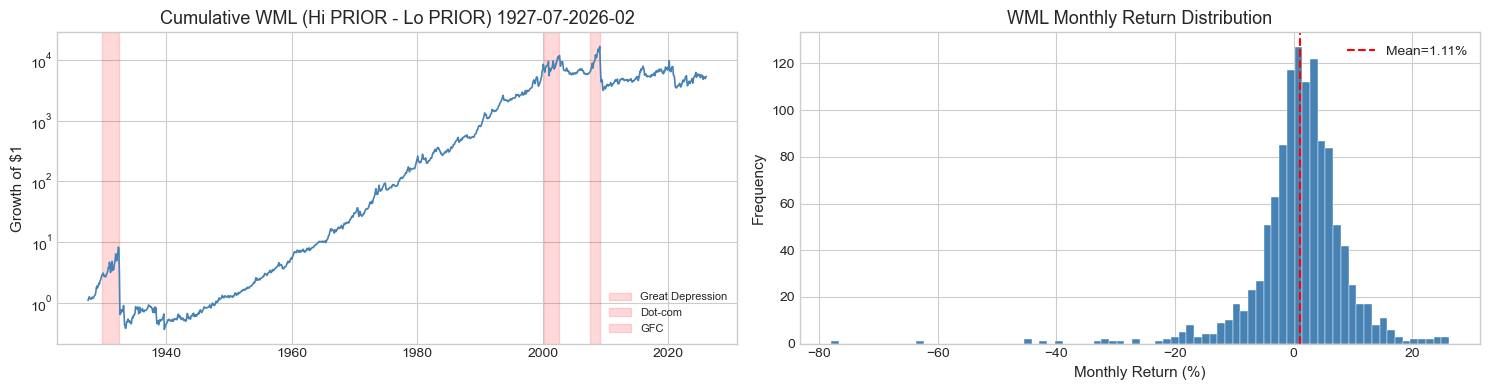

Plot saved: eda_wml.png
[log] state written -> C:\Users\User\Documents\pmm\cell_state_log.md  (Cell 4 — EDA Momentum Deciles)


In [55]:

# =============================================================================
# CELL 4 — EDA: Momentum Decile Portfolios
# Questions to answer:
#   1. What is the usable date range? (paper uses {SAMPLE_START} - {SAMPLE_END})
#   2. Are values in % or decimal? (French library returns %)
#   3. Distribution of Lo PRIOR vs Hi PRIOR — spread, skew
#   4. WML = Hi PRIOR - Lo PRIOR: does it match paper's ~14.98% ann. return?
#   5. Are there NaNs or data gaps?
#   6. Crash periods visible? (1932, 2000-02, 2008-09)
# =============================================================================

# --- 1. restrict to paper's sample window {SAMPLE_START} - {SAMPLE_END} ---
# mom10_monthly index is period[M], French data in percentage points
start = SAMPLE_START
end   = SAMPLE_END
mom  = mom10_monthly.loc[start:end].copy()

print(f"Sample window : {mom.index[0]} -> {mom.index[-1]}")
print(f"Months        : {len(mom)}")
print(f"Columns       : {list(mom.columns)}")
print(f"NaN count     : {mom.isnull().sum().sum()}")
print()

# --- 2. raw WML (winner minus loser) in percentage points ---
wml_raw = mom['Hi PRIOR'] - mom['Lo PRIOR']

# annualized stats
ann_ret   = wml_raw.mean() * 12
ann_vol   = wml_raw.std()  * np.sqrt(12)
ann_sr    = ann_ret / ann_vol
wml_skew  = skew(wml_raw.dropna())
wml_kurt  = kurtosis(wml_raw.dropna(), fisher=True)  # excess kurtosis

print("=== Raw WML (Hi PRIOR - Lo PRIOR) ===")
print(f"  Mean monthly return : {wml_raw.mean():.4f}%")
print(f"  Annualized return   : {ann_ret:.2f}%   (paper Table 1: 14.98%)")
print(f"  Annualized vol      : {ann_vol:.2f}%")
print(f"  Annualized SR       : {ann_sr:.4f}    (paper Table 1: 0.52)")
print(f"  Skewness            : {wml_skew:.4f}  (paper: -2.33)")
print(f"  Excess kurtosis     : {wml_kurt:.4f}  (paper: 17.48)")
print()

# --- 3. check data is in % (should see values like 1.2, -3.4, not 0.012) ---
print("=== Sample values (confirm % not decimal) ===")
print(mom[['Lo PRIOR','Hi PRIOR']].head(5))
print()

# --- 4. crash periods: worst WML months ---
print("=== 10 worst WML months (crash exposure) ===")
worst = wml_raw.nsmallest(10)
for dt, val in worst.items():
    print(f"  {dt}  {val:+.2f}%")
print()

# --- 5. best WML months ---
print("=== 10 best WML months ===")
best = wml_raw.nlargest(10)
for dt, val in best.items():
    print(f"  {dt}  {val:+.2f}%")
print()

# --- 6. decile spread plot ---
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# cumulative WML
cum_wml = (1 + wml_raw / 100).cumprod()
cum_wml.index = cum_wml.index.to_timestamp()
axes[0].plot(cum_wml.index, cum_wml.values, color='steelblue', lw=1.2)
axes[0].set_title(f'Cumulative WML (Hi PRIOR - Lo PRIOR) {SAMPLE_START}-{SAMPLE_END}')
axes[0].set_ylabel('Growth of $1')
axes[0].set_yscale('log')
# shade key crash periods
for s, e_crash, label in [('1929-09','1932-06','Great Depression'),
                           ('2000-03','2002-09','Dot-com'),
                           ('2007-08','2009-03','GFC')]:
    axes[0].axvspan(pd.Timestamp(s), pd.Timestamp(e_crash), alpha=0.15, color='red', label=label)
axes[0].legend(fontsize=8)

# return distribution
axes[1].hist(wml_raw.dropna(), bins=80, color='steelblue', edgecolor='white', lw=0.3)
axes[1].axvline(wml_raw.mean(), color='red', lw=1.5, linestyle='--', label=f'Mean={wml_raw.mean():.2f}%')
axes[1].set_title('WML Monthly Return Distribution')
axes[1].set_xlabel('Monthly Return (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\User\Documents\pmm\eda_wml.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved: eda_wml.png")

# --- log state ---
log_state("Cell 4 — EDA Momentum Deciles", {
    "mom"     : mom,
    "wml_raw" : wml_raw,
    "ann_ret_wml" : ann_ret,
    "ann_sr_wml"  : ann_sr,
})


Daily market returns: 1926-07-01 -> 2026-02-27
Observations        : 26,190
NaN count           : 0

=== Daily market return distribution ===
  Mean             : 0.0428%
  Std              : 1.0778%
  Skewness         : -0.1663  (negative = fat left tail)
  Excess kurtosis  : 16.1480

  # positive days  : 14,502 (55.4%)
  # negative days  : 11,688 (44.6%)

=== Squared return asymmetry (key PMM motivation) ===
  E[r^2 | r>=0]    : 1.0580 x10^-4
  E[r^2 | r<0]     : 1.2942 x10^-4
  Ratio neg/pos    : 1.2232
  => negative days contribute 55.0% of total squared returns

=== Rolling RPM preview (126-day window) ===
  RPM+ mean : 0.001234
  RPM- mean : 0.001216
  Ratio neg/pos mean : 1.0019  (>1 means downside dominates on average)



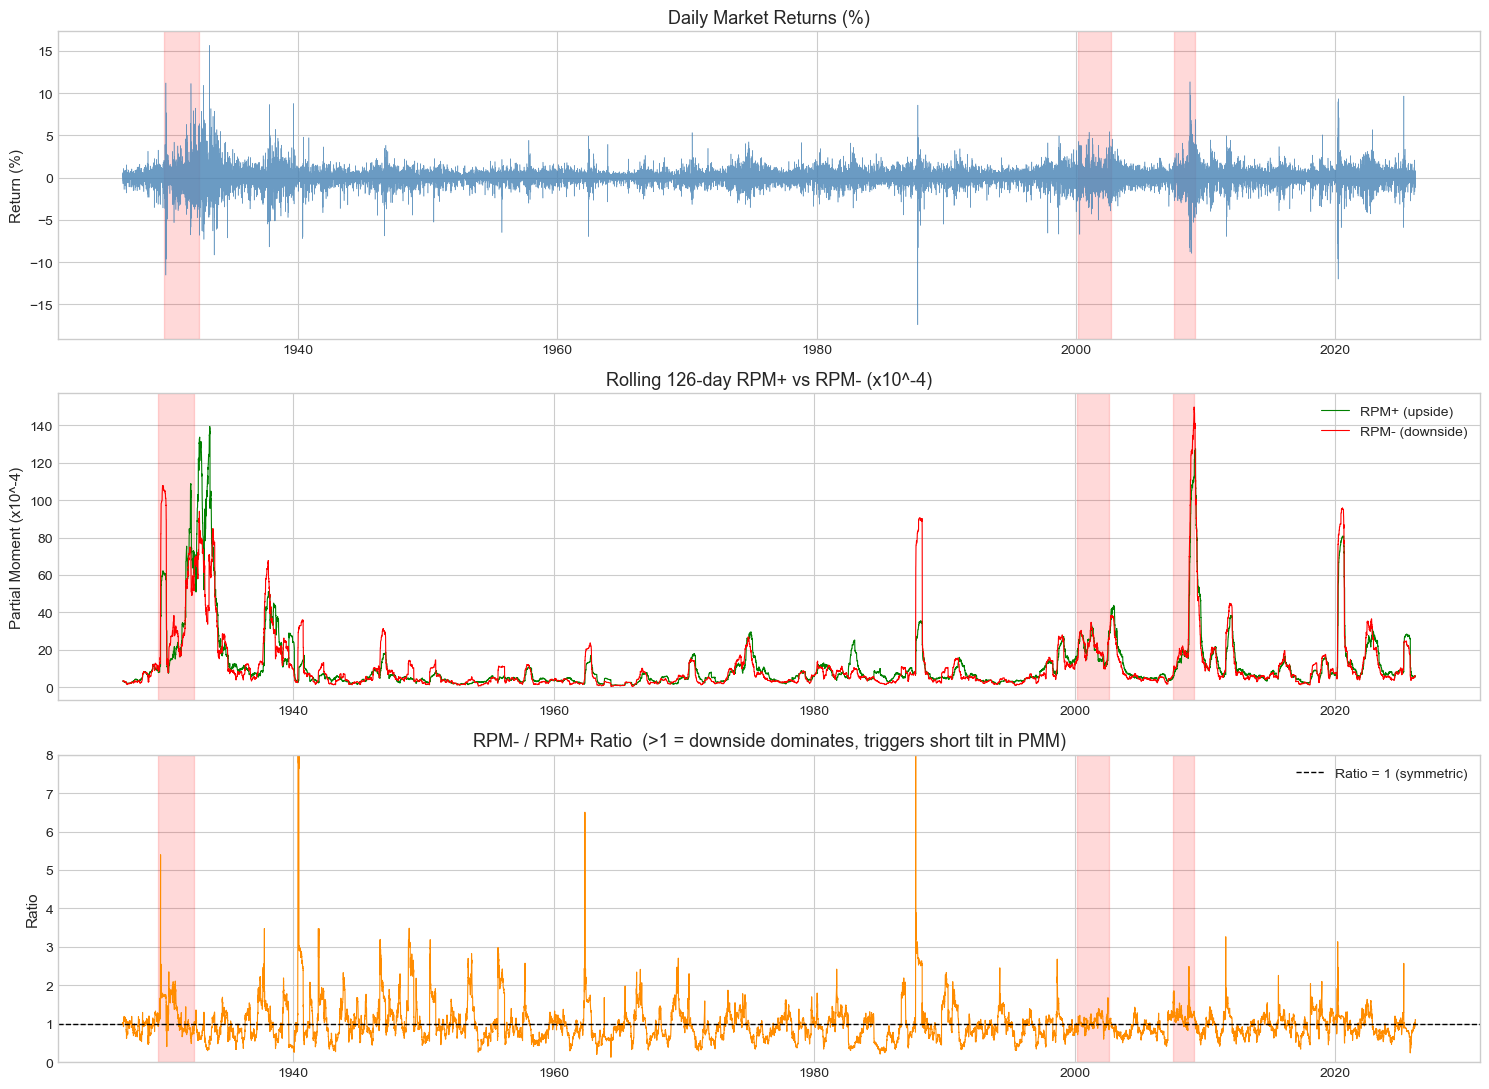

Plot saved: eda_rpm.png

=== EDA Conclusions informing implementation ===
  1. Negative returns have 1.22x larger squared returns -> RPM- > RPM+ on average
  2. Ratio RPM-/RPM+ spikes sharply in crash periods -> PMM short tilt is well-timed
  3. Daily data has no NaNs, full coverage 1926-2026-02
  4. Data is in decimal form after /100 conversion
[log] state written -> C:\Users\User\Documents\pmm\cell_state_log.md  (Cell 5 — EDA Daily Market Returns)


In [56]:

# =============================================================================
# CELL 5 — EDA: Daily Market Returns
# RPM+ and RPM- are built from daily market returns (eq. 4 & 5).
# Key questions:
#   1. Is the distribution of daily market returns skewed? (confirms RPM- != RPM+)
#   2. Are negative returns larger in magnitude than positive? (asymmetry)
#   3. Do crash periods show clear RPM- spikes vs RPM+?
#   4. Volatility clustering — confirms forecastability argument (Appendix B)
#   5. Ratio RPM-/RPM+ over time — should spike above 1 in crashes
# =============================================================================

# --- reconstruct full daily market return = Mkt-RF + RF (both in %) ---
# French library gives percentage values
mkt_daily = (ff_daily['Mkt-RF'] + ff_daily['RF']) / 100   # convert to decimal

# restrict to paper window: need daily data starting mid-1926 for the 126-day
# lookback to be available from Jul 1927
mkt_daily = mkt_daily.loc['1926-01-01':DAILY_END]

print(f"Daily market returns: {mkt_daily.index[0].date()} -> {mkt_daily.index[-1].date()}")
print(f"Observations        : {len(mkt_daily):,}")
print(f"NaN count           : {mkt_daily.isnull().sum()}")
print()

# --- 1. distributional properties ---
pos_ret = mkt_daily[mkt_daily >= 0]
neg_ret = mkt_daily[mkt_daily <  0]

print("=== Daily market return distribution ===")
print(f"  Mean             : {mkt_daily.mean()*100:.4f}%")
print(f"  Std              : {mkt_daily.std()*100:.4f}%")
print(f"  Skewness         : {skew(mkt_daily):.4f}  (negative = fat left tail)")
print(f"  Excess kurtosis  : {kurtosis(mkt_daily, fisher=True):.4f}")
print()
print(f"  # positive days  : {len(pos_ret):,} ({len(pos_ret)/len(mkt_daily)*100:.1f}%)")
print(f"  # negative days  : {len(neg_ret):,} ({len(neg_ret)/len(mkt_daily)*100:.1f}%)")
print()

# --- 2. asymmetry: mean squared return by sign ---
# E[r^2 | r>=0] vs E[r^2 | r<0] — core motivation for RPM
mean_sq_pos = np.mean(pos_ret.values**2)
mean_sq_neg = np.mean(neg_ret.values**2)
print("=== Squared return asymmetry (key PMM motivation) ===")
print(f"  E[r^2 | r>=0]    : {mean_sq_pos*1e4:.4f} x10^-4")
print(f"  E[r^2 | r<0]     : {mean_sq_neg*1e4:.4f} x10^-4")
print(f"  Ratio neg/pos    : {mean_sq_neg/mean_sq_pos:.4f}")
print(f"  => negative days contribute {mean_sq_neg/(mean_sq_pos+mean_sq_neg)*100:.1f}% of total squared returns")
print()

# --- 3. rolling 126-day RPM+ and RPM- preview (vectorized, fast) ---
# using numpy stride tricks for speed
r_arr = mkt_daily.values.astype(np.float64)
n     = len(r_arr)
win   = RPM_WINDOW

# vectorized rolling partial moments
# for each month-end we'll do this properly in Cell 7 with numba
# here we just use rolling pandas for EDA visibility
r2 = pd.Series(r_arr**2, index=mkt_daily.index)
r2_pos = r2.where(mkt_daily.values >= 0, 0.0)   # r^2 if positive else 0
r2_neg = r2.where(mkt_daily.values <  0, 0.0)   # r^2 if negative else 0

rpm_pos_roll = r2_pos.rolling(win).sum() * (21/126)
rpm_neg_roll = r2_neg.rolling(win).sum() * (21/126)
ratio_roll   = rpm_neg_roll / rpm_pos_roll       # >1 means downside dominated

print(f"=== Rolling RPM preview (126-day window) ===")
print(f"  RPM+ mean : {rpm_pos_roll.mean():.6f}")
print(f"  RPM- mean : {rpm_neg_roll.mean():.6f}")
print(f"  Ratio neg/pos mean : {ratio_roll.mean():.4f}  (>1 means downside dominates on average)")
print()

# --- 4. plot ---
fig, axes = plt.subplots(3, 1, figsize=(15, 11))

# panel A: daily returns
axes[0].plot(mkt_daily.index, mkt_daily.values * 100, color='steelblue', lw=0.4, alpha=0.8)
axes[0].set_title('Daily Market Returns (%)')
axes[0].set_ylabel('Return (%)')
for s, e_crash in [('1929-09-01','1932-06-01'),('2000-03-01','2002-09-01'),('2007-08-01','2009-03-01')]:
    axes[0].axvspan(pd.Timestamp(s), pd.Timestamp(e_crash), alpha=0.15, color='red')

# panel B: rolling RPM+ vs RPM-
axes[1].plot(rpm_pos_roll.index, rpm_pos_roll.values * 1e4, color='green', lw=0.8, label='RPM+ (upside)')
axes[1].plot(rpm_neg_roll.index, rpm_neg_roll.values * 1e4, color='red',   lw=0.8, label='RPM- (downside)')
axes[1].set_title('Rolling 126-day RPM+ vs RPM- (x10^-4)')
axes[1].set_ylabel('Partial Moment (x10^-4)')
axes[1].legend()
for s, e_crash in [('1929-09-01','1932-06-01'),('2000-03-01','2002-09-01'),('2007-08-01','2009-03-01')]:
    axes[1].axvspan(pd.Timestamp(s), pd.Timestamp(e_crash), alpha=0.15, color='red')

# panel C: ratio RPM-/RPM+
axes[2].plot(ratio_roll.index, ratio_roll.values, color='darkorange', lw=0.8)
axes[2].axhline(1.0, color='black', lw=1, linestyle='--', label='Ratio = 1 (symmetric)')
axes[2].set_title('RPM- / RPM+ Ratio  (>1 = downside dominates, triggers short tilt in PMM)')
axes[2].set_ylabel('Ratio')
axes[2].set_ylim(0, 8)
axes[2].legend()
for s, e_crash in [('1929-09-01','1932-06-01'),('2000-03-01','2002-09-01'),('2007-08-01','2009-03-01')]:
    axes[2].axvspan(pd.Timestamp(s), pd.Timestamp(e_crash), alpha=0.15, color='red')

plt.tight_layout()
plt.savefig(r'C:\Users\User\Documents\pmm\eda_rpm.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved: eda_rpm.png")
print()

# --- EDA conclusion ---
print("=== EDA Conclusions informing implementation ===")
print(f"  1. Negative returns have {mean_sq_neg/mean_sq_pos:.2f}x larger squared returns -> RPM- > RPM+ on average")
print(f"  2. Ratio RPM-/RPM+ spikes sharply in crash periods -> PMM short tilt is well-timed")
print(f"  3. Daily data has no NaNs, full coverage 1926-{SAMPLE_END}")
print(f"  4. Data is in decimal form after /100 conversion")

log_state("Cell 5 — EDA Daily Market Returns", {
    "mkt_daily"    : mkt_daily,
    "rpm_pos_roll" : rpm_pos_roll,
    "rpm_neg_roll" : rpm_neg_roll,
    "ratio_roll"   : ratio_roll,
    "mean_sq_pos"  : mean_sq_pos,
    "mean_sq_neg"  : mean_sq_neg,
})


In [57]:

# =============================================================================
# CELL 6 — WML Portfolio Construction
# Build clean aligned dataset for all strategy computations:
#   - wml    : winner minus loser monthly return (decimal)
#   - r_win  : winner (Hi PRIOR) monthly return (decimal)
#   - r_los  : loser  (Lo PRIOR) monthly return (decimal)
#   - rf     : monthly risk-free rate (decimal)
#   - mkt_ret: monthly market excess return (decimal) for factor models
#
# EDA informed decisions:
#   - Data is in % -> divide by 100 for all computations
#   - No NaNs in decile data for our window
#   - Use period[M] index throughout for clean month alignment
#   - Paper window: {SAMPLE_START} - {SAMPLE_END}
# =============================================================================

# paper window — self-contained if Cell 4 was skipped
if 'mom10_monthly' not in globals() or 'ff_monthly' not in globals():
    raise RuntimeError('Run Cell 2 first (mom10_monthly, ff_monthly)')
start = SAMPLE_START
end   = SAMPLE_END
mom   = mom10_monthly.loc[start:end].copy()

# --- convert monthly decile returns from % to decimal ---
r_win = mom['Hi PRIOR'] / 100    # winner decile (P10), decimal
r_los = mom['Lo PRIOR'] / 100    # loser  decile (P1),  decimal
wml   = r_win - r_los            # raw WML (long winner, short loser), decimal

# --- monthly RF from ff_monthly (also in %, convert to decimal) ---
rf_monthly = ff_monthly['RF'] / 100
rf_monthly = rf_monthly.loc[start:end]

# --- monthly market excess return ---
mkt_excess = ff_monthly['Mkt-RF'] / 100
mkt_excess = mkt_excess.loc[start:end]

# --- align all series to same period[M] index ---
# confirm all have identical indices
assert (wml.index == r_win.index).all()
assert (wml.index == r_los.index).all()

# rf and mkt_excess are on the same French monthly index
# check coverage
rf_common = rf_monthly.reindex(wml.index)
mkt_common = mkt_excess.reindex(wml.index)

print("=== Alignment check ===")
print(f"  wml       : {wml.index[0]} -> {wml.index[-1]}  len={len(wml)}")
print(f"  r_win     : {r_win.index[0]} -> {r_win.index[-1]}  len={len(r_win)}")
print(f"  r_los     : {r_los.index[0]} -> {r_los.index[-1]}  len={len(r_los)}")
print(f"  rf        : {rf_common.index[0]} -> {rf_common.index[-1]}  NaN={rf_common.isnull().sum()}")
print(f"  mkt_excess: {mkt_common.index[0]} -> {mkt_common.index[-1]}  NaN={mkt_common.isnull().sum()}")
print()

# --- verify WML stats match paper Table 1 ---
ann_ret_dec = wml.mean() * 12 * 100       # back to % for display
ann_vol_dec = wml.std()  * np.sqrt(12) * 100
ann_sr_dec  = (wml.mean() * 12) / (wml.std() * np.sqrt(12))
mdd         = (((1 + wml).cumprod() / (1 + wml).cumprod().cummax()) - 1).min() * 100

print("=== WML verification vs paper Table 1 ===")
print(f"  Ann. return    : {ann_ret_dec:.2f}%  (paper: 14.98%)")
print(f"  Ann. Sharpe    : {ann_sr_dec:.4f}    (paper: 0.52)")
print(f"  Skewness       : {skew(wml):.4f}     (paper: -2.33)")
print(f"  Excess kurtosis: {kurtosis(wml, fisher=True):.4f}   (paper: 17.48)")
print(f"  Max Drawdown   : {mdd:.2f}%          (paper: -95.45%)")
print()

# --- package into a clean DataFrame for downstream cells ---
returns_df = pd.DataFrame({
    'r_win'     : r_win,
    'r_los'     : r_los,
    'wml'       : wml,
    'rf'        : rf_common,
    'mkt_excess': mkt_common,
}, index=wml.index)

print("=== returns_df ===")
print(returns_df.head(5))
print(f"\nShape: {returns_df.shape}, NaNs: {returns_df.isnull().sum().sum()}")

log_state("Cell 6 — WML Construction", {
    "returns_df" : returns_df,
    "r_win"      : r_win,
    "r_los"      : r_los,
    "wml"        : wml,
    "rf_common"  : rf_common,
})


=== Alignment check ===
  wml       : 1927-07 -> 2026-02  len=1184
  r_win     : 1927-07 -> 2026-02  len=1184
  r_los     : 1927-07 -> 2026-02  len=1184
  rf        : 1927-07 -> 2026-02  NaN=0
  mkt_excess: 1927-07 -> 2026-02  NaN=0

=== WML verification vs paper Table 1 ===
  Ann. return    : 13.34%  (paper: 14.98%)
  Ann. Sharpe    : 0.4865    (paper: 0.52)
  Skewness       : -2.1915     (paper: -2.33)
  Excess kurtosis: 15.9462   (paper: 17.48)
  Max Drawdown   : -95.60%          (paper: -95.45%)

=== returns_df ===
         r_win   r_los   wml     rf     mkt_excess
Date                                              
1927-07  0.1333  0.0411  0.0922 0.0030  0.0726    
1927-08  0.0548 -0.0054  0.0602 0.0028  0.0199    
1927-09  0.0729 -0.0039  0.0768 0.0021  0.0477    
1927-10 -0.0604 -0.0606  0.0002 0.0025 -0.0429    
1927-11  0.0621  0.1364 -0.0743 0.0021  0.0652    

Shape: (1184, 5), NaNs: 0
[log] state written -> C:\Users\User\Documents\pmm\cell_state_log.md  (Cell 6 — WML Constru

In [58]:

# =============================================================================
# CELL 7 — RPM+/RPM- Computation (Numba JIT optimized)
# Paper eq. (4) and (5):
#   RPM+_t = (21/126) * sum_{j=1}^{126} r^2_{d,t-j} * I(r_{d,t-j} >= 0)
#   RPM-_t = (21/126) * sum_{j=1}^{126} r^2_{d,t-j} * I(r_{d,t-j} <  0)
#
# Implementation strategy:
#   - daily market returns stored as flat float64 array (fast)
#   - for each month in our sample, locate last trading day index in daily array
#   - numba JIT inner loop: O(126 * n_months) — ~138,000 operations, near instant
#   - no-look-ahead: RPM at month t uses data up to and including last day of month t
#     applied to scale returns of month t+1
# =============================================================================

@jit(nopython=True, cache=True)
def _compute_rpm(r_daily, month_end_pos, window, scale):
    """
    Numba JIT core: compute RPM+ and RPM- for each month end position.

    Parameters
    ----------
    r_daily       : 1D float64 array of daily market returns (decimal)
    month_end_pos : 1D int array, index into r_daily for each month's last trading day
    window        : int, lookback window (126)
    scale         : float, 21/126

    Returns
    -------
    rpm_pos : 1D float64 array, RPM+ for each month
    rpm_neg : 1D float64 array, RPM- for each month
    """
    n      = len(month_end_pos)
    rpm_pos = np.empty(n, dtype=np.float64)
    rpm_neg = np.empty(n, dtype=np.float64)

    for i in range(n):
        pos = month_end_pos[i]
        # start index: go back 'window' days from pos (inclusive of pos)
        start = pos - window + 1
        if start < 0:
            # not enough history — set NaN sentinel
            rpm_pos[i] = np.nan
            rpm_neg[i] = np.nan
            continue

        s_pos = 0.0
        s_neg = 0.0
        for j in range(start, pos + 1):
            r  = r_daily[j]
            r2 = r * r
            if r >= 0.0:
                s_pos += r2
            else:
                s_neg += r2

        rpm_pos[i] = scale * s_pos
        rpm_neg[i] = scale * s_neg

    return rpm_pos, rpm_neg

# --- prepare daily return array (decimal) ---
# mkt_daily was built in cell 5 but scoped there; rebuild from ff_daily
mkt_d = (ff_daily['Mkt-RF'] + ff_daily['RF']) / 100
mkt_d = mkt_d.loc['1926-01-01':DAILY_END]
r_daily_arr = mkt_d.values.astype(np.float64)
daily_dates = mkt_d.index  # DatetimeIndex

# --- find last trading day position for each month in our returns_df ---
# returns_df.index is period[M] — convert to month-end timestamps
month_periods = returns_df.index   # period[M]

month_end_positions = np.empty(len(month_periods), dtype=np.int64)

for i, period in enumerate(month_periods):
    # find all daily dates in this month
    month_start = period.to_timestamp(how='S')
    month_end   = period.to_timestamp(how='E')
    # boolean mask — last trading day of this month
    mask = (daily_dates >= month_start) & (daily_dates <= month_end)
    idx  = np.where(mask)[0]
    if len(idx) == 0:
        month_end_positions[i] = -1   # no trading day found (shouldn't happen)
    else:
        month_end_positions[i] = idx[-1]   # last trading day of month

missing = (month_end_positions == -1).sum()
print(f"Month-end position mapping: {len(month_end_positions)} months, {missing} missing")

# --- warm up numba (first call triggers JIT compilation) ---
print("Compiling numba JIT (first call)...")
t0 = time.time()
_ = _compute_rpm(r_daily_arr[:200], month_end_positions[:5], RPM_WINDOW, SCALE)
print(f"  JIT compile done in {time.time()-t0:.2f}s")

# --- full run ---
print("Running full RPM computation...")
t0 = time.time()
rpm_pos_arr, rpm_neg_arr = _compute_rpm(
    r_daily_arr, month_end_positions, RPM_WINDOW, SCALE
)
elapsed = time.time() - t0
print(f"  Done in {elapsed*1000:.1f}ms for {len(month_periods)} months")

# --- pack into Series aligned to returns_df.index ---
rpm_pos = pd.Series(rpm_pos_arr, index=returns_df.index, name='RPM_pos')
rpm_neg = pd.Series(rpm_neg_arr, index=returns_df.index, name='RPM_neg')
rv      = rpm_pos + rpm_neg   # realized variance identity: RV = RPM+ + RPM-

# --- NaN check: first ~6 months may lack 126-day history ---
nan_count = rpm_pos.isnull().sum()
first_valid = rpm_pos.first_valid_index()
print(f"\nNaN months (insufficient history): {nan_count}")
print(f"First valid RPM month: {first_valid}")
print()

# --- verify: when RPM+ ~ RPM-, ratio should be near 1 (calm periods) ---
ratio = rpm_neg / rpm_pos
print("=== RPM stats ===")
print(f"  RPM+ mean : {rpm_pos.mean():.6f}")
print(f"  RPM- mean : {rpm_neg.mean():.6f}")
print(f"  RV   mean : {rv.mean():.6f}")
print(f"  RPM-/RPM+ mean ratio : {ratio.mean():.4f}  (>1 confirms downside dominance)")
print()

# --- spot check crash period: 2008-09 should have RPM- >> RPM+ ---
print("=== RPM during GFC (2007-08 to 2009-03) ===")
gfc_mask = (returns_df.index >= pd.Period('2007-08','M')) & \
           (returns_df.index <= pd.Period('2009-03','M'))
gfc_rpm = pd.DataFrame({'RPM+': rpm_pos[gfc_mask], 'RPM-': rpm_neg[gfc_mask],
                         'ratio': ratio[gfc_mask]})
print(gfc_rpm.to_string())

log_state("Cell 7 — RPM Computation", {
    "rpm_pos"  : rpm_pos,
    "rpm_neg"  : rpm_neg,
    "rv"       : rv,
    "ratio"    : ratio,
})


Month-end position mapping: 1184 months, 0 missing
Compiling numba JIT (first call)...
  JIT compile done in 0.53s
Running full RPM computation...
  Done in 1.0ms for 1184 months

NaN months (insufficient history): 0
First valid RPM month: 1927-07

=== RPM stats ===
  RPM+ mean : 0.001211
  RPM- mean : 0.001198
  RV   mean : 0.002409
  RPM-/RPM+ mean ratio : 0.9939  (>1 confirms downside dominance)

=== RPM during GFC (2007-08 to 2009-03) ===
         RPM+   RPM-   ratio
Date                        
2007-08 0.0009 0.0010 1.1849
2007-09 0.0009 0.0010 1.0792
2007-10 0.0010 0.0011 1.1364
2007-11 0.0013 0.0016 1.1924
2007-12 0.0014 0.0017 1.2080
2008-01 0.0015 0.0019 1.2444
2008-02 0.0013 0.0018 1.3699
2008-03 0.0017 0.0021 1.2227
2008-04 0.0020 0.0021 1.0653
2008-05 0.0017 0.0017 1.0205
2008-06 0.0016 0.0019 1.1712
2008-07 0.0018 0.0018 0.9960
2008-08 0.0019 0.0016 0.8447
2008-09 0.0023 0.0037 1.6076
2008-10 0.0067 0.0080 1.2012
2008-11 0.0093 0.0111 1.1908
2008-12 0.0107 0.0125 1.1694
20

In [59]:

# =============================================================================
# CELL 8 — VM, PMM, PMMC Strategy Returns
#
# VM  (Barroso & Santa-Clara 2015): equal-weight long/short scaled by vol
#   phi_vm = sigma_tar / sqrt(RV_t)
#   r_vm   = phi_vm * wml  (net zero, no cash leg needed — weights cancel)
#
# PMM (paper eq. 6, 8, 9):
#   phi1 = (2*sigma_tar/sqrt(RV_t)) * (RPM+_t / RV_t)   — long weight
#   phi2 = (2*sigma_tar/sqrt(RV_t)) * (RPM-_t / RV_t)   — short weight
#   r_pmm = phi1*r_win - phi2*r_los + (phi2-phi1)*rf
#
# PMMC (paper eq. 10, 11): apply 200% leverage cap
#   if phi1+phi2 > MAX_LEV: rescale to phi1=2*RPM+/RV, phi2=2*RPM-/RV
#
# KEY: sigma_tar = 0.12 annualized, as written in paper eq. (8)-(9).
#   RV_t from eq. (4)-(5) is monthly variance; annualize inside the sqrt
#   as sqrt(12 * RV_t) so units match: sigma_tar / sqrt(RV_annual).
#
# numexpr used for large vector arithmetic (weight formulas)
# All series aligned on same period[M] index as returns_df
# Weights computed at t, returns realized at t+1 — no look-ahead
# =============================================================================

rv_arr      = rv.values.astype(np.float64)        # RV_t
rpm_pos_arr = rpm_pos.values.astype(np.float64)   # RPM+_t
rpm_neg_arr = rpm_neg.values.astype(np.float64)   # RPM-_t

# sigma_tar = 0.12 annualized, exactly as in paper eq. (8)-(9)
# RV_t is monthly (SCALE=21/126); annualize via sqrt(12 * rv_arr) in formula
sigma_tar   = SIGMA_TAR                             # 0.12 annualized, paper eq. (8)-(9)

# --- VM weights (scalar scaling, both legs equal) ---
# phi_vm_t = sigma_tar / sqrt(RV_t)
# numexpr for element-wise speed
phi_vm = ne.evaluate("sigma_tar / sqrt(12 * rv_arr)",
                     local_dict={'sigma_tar': sigma_tar, 'rv_arr': rv_arr})

# --- PMM weights (eq. 8 & 9) ---
# phi1 = (2*sigma_tar/sqrt(RV)) * (RPM+/RV)
# phi2 = (2*sigma_tar/sqrt(RV)) * (RPM-/RV)
phi1 = ne.evaluate("2*sigma_tar / sqrt(12 * rv_arr) * rpm_pos_arr / rv_arr",
                   local_dict={'sigma_tar': sigma_tar, 'rv_arr': rv_arr,
                               'rpm_pos_arr': rpm_pos_arr})
phi2 = ne.evaluate("2*sigma_tar / sqrt(12 * rv_arr) * rpm_neg_arr / rv_arr",
                   local_dict={'sigma_tar': sigma_tar, 'rv_arr': rv_arr,
                               'rpm_neg_arr': rpm_neg_arr})

leverage_pmm = phi1 + phi2  # = 2*sigma_tar/sqrt(RV) for both legs

# --- PMMC weights (eq. 10 & 11) — cap at MAX_LEV=2.0 ---
phi1_c = phi1.copy()
phi2_c = phi2.copy()
cap_mask = leverage_pmm > MAX_LEV
phi1_c[cap_mask] = ne.evaluate(
    "2.0 * rpm_pos_arr / rv_arr",
    local_dict={'rpm_pos_arr': rpm_pos_arr[cap_mask], 'rv_arr': rv_arr[cap_mask]}
)
phi2_c[cap_mask] = ne.evaluate(
    "2.0 * rpm_neg_arr / rv_arr",
    local_dict={'rpm_neg_arr': rpm_neg_arr[cap_mask], 'rv_arr': rv_arr[cap_mask]}
)

print("=== Weight diagnostics ===")
print(f"  phi_vm   : mean={phi_vm.mean():.4f}  std={phi_vm.std():.4f}  "
      f"min={phi_vm.min():.4f}  max={phi_vm.max():.4f}")
print(f"  phi1 (L) : mean={phi1.mean():.4f}  std={phi1.std():.4f}  "
      f"min={phi1.min():.4f}  max={phi1.max():.4f}  (paper: mean=1.05, std=0.52)")
print(f"  phi2 (S) : mean={phi2.mean():.4f}  std={phi2.std():.4f}  "
      f"min={phi2.min():.4f}  max={phi2.max():.4f}  (paper: mean=0.93, std=0.38)")
print(f"  PMM leverage (phi1+phi2): mean={leverage_pmm.mean():.4f}")
print(f"  Months where leverage > 200%: {cap_mask.sum()} "
      f"({cap_mask.mean()*100:.1f}% of sample)")
print()

# --- Strategy returns (shift weights by 1 month: weight at t applied to t+1 return) ---
r_win_arr = returns_df['r_win'].values.astype(np.float64)
r_los_arr = returns_df['r_los'].values.astype(np.float64)
wml_arr   = returns_df['wml'].values.astype(np.float64)
rf_arr    = returns_df['rf'].values.astype(np.float64)

# shift: weight[t] * return[t+1]  =>  use phi[:-1] * ret[1:]
# result is indexed from month index[1] onward
idx = returns_df.index

# VM: phi_vm[t] * (r_win[t+1] - r_los[t+1])  =>  phi_vm[t] * wml[t+1]
r_vm  = phi_vm[:-1] * wml_arr[1:]

# PMM: phi1[t]*r_win[t+1] - phi2[t]*r_los[t+1] + (phi2[t]-phi1[t])*rf[t+1]
r_pmm = phi1[:-1] * r_win_arr[1:] - phi2[:-1] * r_los_arr[1:] + \
        (phi2[:-1] - phi1[:-1]) * rf_arr[1:]

# PMMC: same with capped weights
r_pmmc = phi1_c[:-1] * r_win_arr[1:] - phi2_c[:-1] * r_los_arr[1:] + \
         (phi2_c[:-1] - phi1_c[:-1]) * rf_arr[1:]

# plain WML (no scaling) — same index as scaled strategies
r_wml = wml_arr[1:]

# align to index (drop first month since weight from t-1 needed)
strat_idx = idx[1:]

strategies = pd.DataFrame({
    'WML'  : r_wml,
    'VM'   : r_vm,
    'PMM'  : r_pmm,
    'PMMC' : r_pmmc,
}, index=strat_idx)

print("=== Strategy returns DataFrame ===")
print(f"  Shape : {strategies.shape}")
print(f"  Index : {strategies.index[0]} -> {strategies.index[-1]}")
print(f"  NaNs  : {strategies.isnull().sum().to_dict()}")
print()
print(strategies.head(8))
print()

# quick verification vs paper Table 1
print("=== Annualized stats vs paper Table 1 ===")
targets = {'WML': (14.98, 0.52), 'VM': (18.19, 1.02),
           'PMM': (20.44, 1.23), 'PMMC': (18.71, 1.11)}
for col in strategies.columns:
    s   = strategies[col]
    ar  = s.mean() * 12 * 100
    sr  = (s.mean() * 12) / (s.std() * np.sqrt(12))
    mdd = (((1 + s).cumprod() / (1 + s).cumprod().cummax()) - 1).min() * 100
    t_ar, t_sr = targets[col]
    print(f"  {col:5s}  ann.ret={ar:6.2f}%  SR={sr:.4f}  MDD={mdd:.2f}%"
          f"   (paper: ret={t_ar:.2f}%  SR={t_sr:.2f})")

log_state("Cell 8 — Strategy Returns", {
    "strategies" : strategies,
    "phi1"       : pd.Series(phi1, index=idx, name='phi1'),
    "phi2"       : pd.Series(phi2, index=idx, name='phi2'),
    "phi_vm"     : pd.Series(phi_vm, index=idx, name='phi_vm'),
})


=== Weight diagnostics ===
  phi_vm   : mean=0.9891  std=0.3977  min=0.2165  max=2.5268
  phi1 (L) : mean=1.0520  std=0.5108  min=0.1352  max=3.6444  (paper: mean=1.05, std=0.52)
  phi2 (S) : mean=0.9262  std=0.3771  min=0.1430  max=2.3666  (paper: mean=0.93, std=0.38)
  PMM leverage (phi1+phi2): mean=1.9782
  Months where leverage > 200%: 551 (46.5% of sample)

=== Strategy returns DataFrame ===
  Shape : (1183, 4)
  Index : 1927-08 -> 2026-02
  NaNs  : {'WML': 0, 'VM': 0, 'PMM': 0, 'PMMC': 0}

         WML     VM      PMM     PMMC  
Date                                   
1927-08  0.0602  0.0949  0.0946  0.0600
1927-09  0.0768  0.1152  0.1169  0.0779
1927-10  0.0002  0.0003 -0.0324 -0.0230
1927-11 -0.0743 -0.0945 -0.0910 -0.0716
1927-12  0.0035  0.0045  0.0275  0.0215
1928-01 -0.0047 -0.0059 -0.0089 -0.0071
1928-02  0.0150  0.0196  0.0173  0.0132
1928-03  0.0573  0.0759  0.0706  0.0533

=== Annualized stats vs paper Table 1 ===
  WML    ann.ret= 13.26%  SR=0.4835  MDD=-95.60%   (pape

In [65]:
# =============================================================================
# PMM CONSTRAINT CHECK
# Verify: phi1 + phi2 == 2 * sigma_tar / sqrt(12 * RV_t) for every month
# Paper eq. (7): phi1 + phi2 = 2 * sigma_tar / sqrt(RV_t)
# (RV_t annualized = 12 * rv, so sqrt(RV_annual) = sqrt(12 * rv))
# =============================================================================

expected = 2 * SIGMA_TAR / np.sqrt(12 * rv.values)
actual   = phi1 + phi2

diff     = np.abs(actual - expected)
max_diff = diff.max()
mean_diff = diff.mean()

print('=== PMM constraint check: phi1 + phi2 == 2*sigma_tar / sqrt(12*RV_t) ===')
print(f'  max  |actual - expected| : {max_diff:.2e}')
print(f'  mean |actual - expected| : {mean_diff:.2e}')
print(f'  constraint holds        : {max_diff < 1e-10}')
print()
print(f'  phi1 + phi2  mean : {actual.mean():.6f}')
print(f'  expected     mean : {expected.mean():.6f}')


=== PMM constraint check: phi1 + phi2 == 2*sigma_tar / sqrt(12*RV_t) ===
  max  |actual - expected| : 8.88e-16
  mean |actual - expected| : 9.25e-17
  constraint holds        : True

  phi1 + phi2  mean : 1.978172
  expected     mean : 1.978172


In [67]:

# =============================================================================
# CELL 9 — Performance Table (replicates paper Table 1)
#
# Metrics for each strategy over whole sample ({SAMPLE_START} - {SAMPLE_END})
# and post-1963 sub-period (Jan 1963 - {SAMPLE_END}):
#   - Annualized return (%) + t-stat
#   - Annualized Sharpe ratio
#   - Adapted Sortino ratio (Appendix A: denominator = downside vol of LS portfolio)
#   - Information ratio vs WML benchmark
#   - Maximum drawdown (%)
#   - Skewness
#   - Excess kurtosis
#   - Jarque-Bera stat + p-value
#
# Sharpe ratio for long-short (Appendix A eq. A.1):
#   SR = mu_LS / sd(LS)   where mu_LS = annualized mean, sd = annualized vol
#
# Adapted Sortino (Appendix A):
#   Sortino = ann_mean / ann_downside_vol
#   ann_downside_vol = sqrt(12) * sqrt(E[min(r_t, 0)^2])  (semi-deviation)
#
# Information ratio:
#   IR = (ann_ret_strat - ann_ret_WML) / ann_tracking_error
#   tracking_error = std(strat - WML) * sqrt(12)
# =============================================================================

from scipy.stats import t as t_dist

def _perf(s, benchmark=None):
    """
    Compute performance metrics for a monthly return series s (decimal).
    benchmark : Series used for information ratio; if None IR is skipped.
    Returns dict of metrics.
    """
    n       = len(s)
    mu_m    = s.mean()                       # mean monthly return
    std_m   = s.std(ddof=1)                  # monthly vol
    ann_ret = mu_m * 12 * 100                # annualized return in %
    ann_vol = std_m * np.sqrt(12) * 100      # annualized vol in %
    ann_sr  = (mu_m * 12) / (std_m * np.sqrt(12))   # annualized Sharpe

    # t-stat on mean
    tstat   = mu_m / (std_m / np.sqrt(n))
    pval    = 2 * (1 - t_dist.cdf(abs(tstat), df=n-1))

    # adapted Sortino: semi-deviation = sqrt(E[min(r,0)^2])
    neg     = s[s < 0]
    semi_m  = np.sqrt((neg**2).mean()) if len(neg) > 0 else np.nan
    sortino = (mu_m * 12) / (semi_m * np.sqrt(12)) if semi_m > 0 else np.nan

    # information ratio vs benchmark
    if benchmark is not None:
        active  = s - benchmark
        ir      = (active.mean() * 12) / (active.std(ddof=1) * np.sqrt(12))
    else:
        ir = np.nan

    # maximum drawdown
    cumret = (1 + s).cumprod()
    mdd    = ((cumret / cumret.cummax()) - 1).min() * 100

    # higher moments (excess kurtosis via fisher=True)
    sk     = float(stats.skew(s))
    ku     = float(stats.kurtosis(s, fisher=True))   # excess kurtosis

    # Jarque-Bera
    jb_stat, jb_p = jarque_bera(s)

    return {
        'ann_ret'   : ann_ret,
        'tstat'     : tstat,
        'pval'      : pval,
        'ann_vol'   : ann_vol,
        'ann_sr'    : ann_sr,
        'sortino'   : sortino,
        'ir'        : ir,
        'mdd'       : mdd,
        'skew'      : sk,
        'kurt'      : ku,
        'jb_stat'   : jb_stat,
        'jb_p'      : jb_p,
    }

def sig_stars(pval):
    if pval < 0.01:  return '***'
    if pval < 0.05:  return '**'
    if pval < 0.10:  return '*'
    return ''

def _print_table(strats_df, label):
    """Print a formatted performance table."""
    wml_s = strats_df['WML']
    print(f"\n{'='*90}")
    print(f"  {label}")
    print(f"{'='*90}")
    hdr = f"  {'Strategy':<8}  {'Ann.Ret%':>8}  {'SR':>6}  {'Sortino':>8}  "
    hdr += f"{'IR':>6}  {'MDD%':>7}  {'Skew':>7}  {'Kurt':>7}  {'JB stat':>10}"
    print(hdr)
    print(f"  {'-'*86}")
    for col in strats_df.columns:
        m = _perf(strats_df[col], benchmark=(wml_s if col != 'WML' else None))
        stars = sig_stars(m['pval'])
        print(f"  {col:<8}  {m['ann_ret']:>7.2f}{stars:<3}  "
              f"{m['ann_sr']:>6.4f}  "
              f"{m['sortino']:>8.4f}  "
              f"{m['ir']:>6.4f}  "
              f"{m['mdd']:>7.2f}  "
              f"{m['skew']:>7.4f}  "
              f"{m['kurt']:>7.4f}  "
              f"{m['jb_stat']:>10.2f}({m['jb_p']:.3f})")
    print(f"{'='*90}")
    print()

# --- whole sample: {SAMPLE_START} - {SAMPLE_END} ---
print(f"=== Performance Table — Whole Sample ({SAMPLE_START} – {SAMPLE_END}) ===")
_print_table(strategies, f"Whole Sample: {SAMPLE_START} to {SAMPLE_END}")

print("\n=== Paper Table 1 reference ===")
print("  WML   ann.ret=14.98***  SR=0.5200  Sortino=0.16  IR=   n/a  MDD=-95.45  Skew=-2.33  Kurt=17.48  JB=10414")
print("  VM    ann.ret=18.19***  SR=1.0200  Sortino=0.58  IR= 0.800  MDD=-34.25  Skew=-0.23  Kurt= 2.06  JB=53.12")
print("  PMM   ann.ret=20.44***  SR=1.2300  Sortino=0.82  IR= 0.910  MDD=-33.90  Skew= 0.03  Kurt= 2.72  JB=83.45")
print("  PMMC  ann.ret=18.71***  SR=1.1100  Sortino=0.73  IR= 0.860  MDD=-26.11  Skew=-0.10  Kurt= 2.63  JB=49.49")

# --- post-1963 sub-period: Jan 1963 - {SAMPLE_END} ---
start63 = pd.Period('1963-01', freq='M')
strat63 = strategies.loc[start63:]
print(f"\nPost-1963 sub-period: {strat63.index[0]} -> {strat63.index[-1]}  ({len(strat63)} months)")
_print_table(strat63, f"Post-1963 Sub-period: Jan 1963 to {SAMPLE_END}")

print("\n=== Paper Table 1 reference (post-1963) ===")
print("  WML   ann.ret=16.49***  SR=0.6400  Sortino=0.13  IR=   n/a  MDD=-80.55  Skew=-1.40  Kurt= 7.87  JB=882")
print("  VM    ann.ret=20.09***  SR=1.1300  Sortino=0.70  IR= 0.740  MDD=-32.33  Skew=-0.12  Kurt= 1.57  JB=44.05")
print("  PMM   ann.ret=21.32***  SR=1.3200  Sortino=1.12  IR= 0.860  MDD=-34.15  Skew=-0.05  Kurt= 2.70  JB=29.23")
print("  PMMC  ann.ret=18.48***  SR=1.2100  Sortino=1.09  IR= 0.820  MDD=-27.58  Skew=-0.11  Kurt= 2.17  JB=25.21")

log_state("Cell 9 — Performance Table", {
    "strategies" : strategies,
})


=== Performance Table — Whole Sample (1927-07 – 2026-02) ===

  Whole Sample: 1927-07 to 2026-02
  Strategy  Ann.Ret%      SR   Sortino      IR     MDD%     Skew     Kurt     JB stat
  --------------------------------------------------------------------------------------
  WML         13.26***  0.4835    0.3914     nan   -95.60  -2.1918  15.9553    13495.51(0.000)
  VM          16.33***  0.8109    0.7934  0.2161   -46.13  -0.2859   2.2681      269.68(0.000)
  PMM         17.89***  0.8319    0.8426  0.2849   -47.52  -0.0929   2.9755      438.12(0.000)
  PMMC        14.74***  0.7798    0.7556  0.0979   -47.52  -0.3964   3.0577      491.85(0.000)


=== Paper Table 1 reference ===
  WML   ann.ret=14.98***  SR=0.5200  Sortino=0.16  IR=   n/a  MDD=-95.45  Skew=-2.33  Kurt=17.48  JB=10414
  VM    ann.ret=18.19***  SR=1.0200  Sortino=0.58  IR= 0.800  MDD=-34.25  Skew=-0.23  Kurt= 2.06  JB=53.12
  PMM   ann.ret=20.44***  SR=1.2300  Sortino=0.82  IR= 0.910  MDD=-33.90  Skew= 0.03  Kurt= 2.72  JB

=== In-sample vs out-of-sample windows ===
  In-sample  : 1927-08 -> 2018-12  (1097 months)
  Out-of-sample: 2019-01 -> 2026-02  (86 months)
  Paper ended 2018-12; extended sample through 2026-02

  In-sample (through 2018-12)
  Strategy  Ann.Ret%      SR   Sortino      IR     MDD%     Skew     Kurt     JB stat
  --------------------------------------------------------------------------------------
  WML         14.17***  0.5238    0.4241     nan   -95.60  -2.3259  17.9590    15731.30(0.000)
  VM          17.19***  0.8628    0.8529  0.2121   -46.13  -0.2636   2.3953      274.96(0.000)
  PMM         18.82***  0.8862    0.9002  0.2832   -40.74  -0.1331   2.9690      406.14(0.000)
  PMMC        15.42***  0.8377    0.8109  0.0826   -40.74  -0.5072   2.8813      426.50(0.000)


  Out-of-sample (2019-01 -> 2026-02)
  Strategy  Ann.Ret%      SR   Sortino      IR     MDD%     Skew     Kurt     JB stat
  --------------------------------------------------------------------------------------
  WM

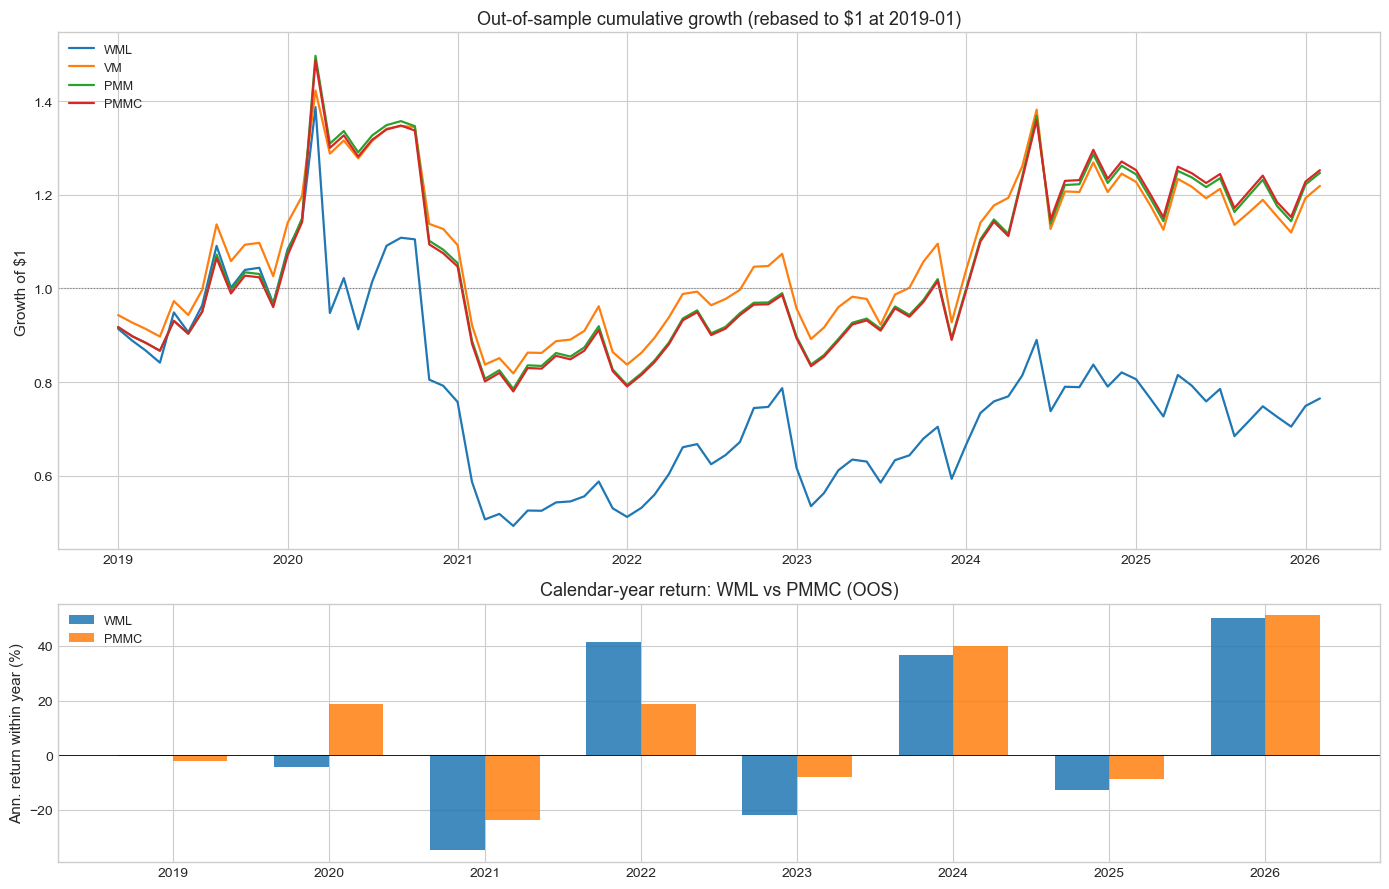


[plot] saved -> C:\Users\User\Documents\pmm\oos_post2018.png
[log] state written -> C:\Users\User\Documents\pmm\cell_state_log.md  (Cell 9b — OOS EDA)


In [90]:

# =============================================================================
# CELL 9b — Out-of-sample EDA (post paper end)
#
# Year-by-year and recent-month view after PAPER_END (2018-12).
# Depends: Cell 8 (`strategies`), Cell 2 (`PAPER_END`, `SAMPLE_END`).
# Optional: Cell 9 (`_perf`, `_print_table`) for headline split tables.
# =============================================================================

for name in ("strategies", "PAPER_END", "SAMPLE_END"):
    if name not in globals():
        raise RuntimeError(f"Run Cell 8 (and Cell 2) first — missing `{name}`")

OOS_START = PAPER_END + 1  # 2019-01

ins = strategies.loc[:PAPER_END]
oos = strategies.loc[OOS_START:]
if oos.empty:
    raise ValueError(f"No OOS months after {PAPER_END}; last index={strategies.index[-1]}")

print("=== In-sample vs out-of-sample windows ===")
print(f"  In-sample  : {ins.index[0]} -> {ins.index[-1]}  ({len(ins)} months)")
print(f"  Out-of-sample: {oos.index[0]} -> {oos.index[-1]}  ({len(oos)} months)")
print(f"  Paper ended {PAPER_END}; extended sample through {SAMPLE_END}")

if "_print_table" in globals():
    _print_table(ins, f"In-sample (through {PAPER_END})")
    _print_table(oos, f"Out-of-sample ({OOS_START} -> {oos.index[-1]})")
else:
    print("\n[hint] Run Cell 9 first for full metric tables on each slice.")


def _oos_year_row(year, g):
    """One calendar year of monthly returns (decimal) -> summary row."""
    n = len(g)
    if n == 0:
        return None
    row = {"year": year, "n": n, "PMMC_yr%": ((1 + g["PMMC"]).prod() - 1) * 100}
    for col in g.columns:
        s = g[col]
        mu = s.mean()
        vol = s.std(ddof=1)
        row[f"{col}_ann%"] = mu * 12 * 100
        row[f"{col}_SR"] = (mu * 12) / (vol * np.sqrt(12)) if vol > 0 and n > 1 else np.nan
        row[f"{col}_mdd%"] = ((1 + s).cumprod() / (1 + s).cumprod().cummax() - 1).min() * 100
    return row


years_oos = sorted(oos.index.year.unique())
rows = [_oos_year_row(y, oos[oos.index.year == y]) for y in years_oos]
yearly = pd.DataFrame(r for r in rows if r is not None).set_index("year")

print("\n=== Out-of-sample — calendar year summary (monthly returns, %) ===")
print("  ann% / SR / mdd% are computed within each calendar year (partial years use fewer months)")
hdr = f"  {'Year':<6} {'n':>3}"
for c in strategies.columns:
    hdr += f"  {c+' ann':>10}  {c+' SR':>7}  {c+' mdd':>8}"
print(hdr)
print("  " + "-" * (len(hdr) - 2))
for y, r in yearly.iterrows():
    line = f"  {int(y):<6} {int(r['n']):>3}  PMMC_yr {r['PMMC_yr%']:>6.2f}%"
    for c in strategies.columns:
        line += f"  {r[f'{c}_ann%']:>9.2f}  {r[f'{c}_SR']:>7.3f}  {r[f'{c}_mdd%']:>7.2f}"
    print(line)
print("  PMMC_yr = calendar-year total return on PMMC (not annualized)")

# --- 2026 month-by-month ---
y2026 = oos.loc["2026"]
print("\n=== 2026 — monthly returns (%) ===")
if y2026.empty:
    print("  (no 2026 months in `strategies` yet)")
else:
    m2026 = (y2026 * 100).round(2)
    m2026.index = m2026.index.astype(str)
    print(m2026.to_string())
    print()
    for col in strategies.columns:
        s = y2026[col]
        ytd = ((1 + s).prod() - 1) * 100
        ann_sc = s.mean() * 12 * 100
        print(f"  {col:5s}  YTD {ytd:+.2f}%  |  x12 scaled ann {ann_sc:+.2f}%  ({len(s)} months)")

# --- OOS cumulative $1 (rebased at OOS start) ---
cum_oos = (1 + oos).cumprod()
cum_oos.index = cum_oos.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [2, 1]})

ax = axes[0]
for col in strategies.columns:
    ax.plot(cum_oos.index, cum_oos[col], label=col, lw=1.6)
ax.axhline(1.0, color="gray", ls=":", lw=0.8)
ax.set_title(f"Out-of-sample cumulative growth (rebased to $1 at {OOS_START})")
ax.set_ylabel("Growth of $1")
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# annual return bars (PMMC vs WML)
ax2 = axes[1]
bar_y = yearly.index.astype(int)
w = 0.35
x = np.arange(len(bar_y))
ax2.bar(x - w / 2, yearly["WML_ann%"], width=w, label="WML", alpha=0.85)
ax2.bar(x + w / 2, yearly["PMMC_ann%"], width=w, label="PMMC", alpha=0.85)
ax2.axhline(0, color="k", lw=0.6)
ax2.set_xticks(x)
ax2.set_xticklabels(bar_y)
ax2.set_ylabel("Ann. return within year (%)")
ax2.set_title("Calendar-year return: WML vs PMMC (OOS)")
ax2.legend(fontsize=9)

plt.tight_layout()
_oos_fig = r"C:\Users\User\Documents\pmm\oos_post2018.png"
plt.savefig(_oos_fig, dpi=130, bbox_inches="tight")
plt.show()
print(f"\n[plot] saved -> {_oos_fig}")

if "log_state" in globals():
    log_state("Cell 9b — OOS EDA", {"oos_yearly": yearly, "oos": oos})


In [68]:

# =============================================================================
# CELL 10 — Market State Analysis (replicates paper Table 2)
#
# Panel A: Petkova & Zhang (2005) expected risk premium states
#   "Trough"   = top 10% of expected risk premium (worst market conditions)
#   "Peak"     = bottom 10% (best conditions)
#   "Recession"= expected premium > mean (excluding Trough)
#   "Expansion"= expected premium < mean (excluding Peak)
#   "Bad"      = Trough + Recession combined
#   "Good"     = Peak + Expansion combined
#   "Non-trough" = everything except Trough
#
#   Petkova-Zhang methodology requires fitting a VAR with state variables
#   (dividend yield, default spread, term spread, T-bill rate) to estimate
#   the conditional expected market risk premium. We replicate their approach
#   using ff_monthly market factor and state variables from FRED.
#   Proxy: fit OLS of future 1-month MKT on lagged state variables; predicted
#   value is the "expected risk premium".
#
# Panel B: NBER business cycle dates (hardcoded, publicly available)
#   "Contraction" = peak to trough (NBER recession)
#   "Non-contraction" = all other months
#
# Report: monthly return mean, t-stat, monthly Sharpe for each state
# =============================================================================

# --- Panel B: NBER contraction dates (hardcoded, peak to trough) ---
# Source: NBER Business Cycle Dating Committee
# Format: (peak_inclusive, trough_inclusive) in YYYY-MM period[M]
NBER_CONTRACTIONS = [
    ('1929-08', '1933-03'),
    ('1937-05', '1938-06'),
    ('1945-02', '1945-10'),
    ('1948-11', '1949-10'),
    ('1953-07', '1954-05'),
    ('1957-08', '1958-04'),
    ('1960-04', '1961-02'),
    ('1969-12', '1970-11'),
    ('1973-11', '1975-03'),
    ('1980-01', '1980-07'),
    ('1981-07', '1982-11'),
    ('1990-07', '1991-03'),
    ('2001-03', '2001-11'),
    ('2007-12', '2009-06'),
]

def _build_nber_mask(index):
    """Return boolean Series: True if period is an NBER contraction month."""
    mask = pd.Series(False, index=index)
    for peak, trough in NBER_CONTRACTIONS:
        p = pd.Period(peak, freq='M')
        t = pd.Period(trough, freq='M')
        mask |= (index >= p) & (index <= t)
    return mask

# strategies index starts at 1927-08
idx = strategies.index
nber_mask = _build_nber_mask(idx)

print(f"NBER contraction months in sample: {nber_mask.sum()} of {len(idx)}")
print(f"  ({nber_mask.mean()*100:.1f}% of sample)\n")

# --- Panel B table ---
def _state_stats(s, mask, label, benchmark_full=None):
    """
    Compute mean return, t-stat, monthly SR for a strategy in/out of a state.
    s : full monthly return Series
    mask : boolean, True = in state
    """
    sub = s[mask]
    if len(sub) == 0:
        return None
    n    = len(sub)
    mu   = sub.mean() * 100           # monthly %, not annualized
    std  = sub.std(ddof=1) * 100
    tstat = (sub.mean()) / (sub.std(ddof=1) / np.sqrt(n))
    sr_m  = sub.mean() / sub.std(ddof=1)   # monthly SR
    return {'n': n, 'mu': mu, 'std': std, 'tstat': tstat, 'sr_m': sr_m}

def _print_panel_b(strategies, nber_mask):
    print("=" * 80)
    print("  Panel B: NBER Contraction vs Non-Contraction")
    print("=" * 80)
    hdr = f"  {'State':<18}  {'n':>5}  {'WML':>12}  {'VM':>12}  {'PMM':>12}  {'PMMC':>12}"
    print(hdr)
    print(f"  {'-'*76}")

    for state_label, mask in [('Contraction', nber_mask), ('Non-contraction', ~nber_mask)]:
        row = f"  {state_label:<18}  {mask.sum():>5}"
        for col in strategies.columns:
            r = _state_stats(strategies[col], mask, state_label)
            if r is None:
                row += f"  {'N/A':>12}"
            else:
                stars = sig_stars(2*(1 - abs(r['tstat'])/np.sqrt(r['n']+r['tstat']**2)))  # approx pval
                from scipy.stats import t as t_dist_inner
                pv = 2*(1 - t_dist_inner.cdf(abs(r['tstat']), df=r['n']-1))
                stars = sig_stars(pv)
                row += f"  {r['mu']:>5.2f}{stars:<3}[{r['sr_m']:>5.2f}]"
        print(row)

    print(f"  {'-'*76}")
    print("  Format: mean_monthly_return%(stars) [monthly_SR]")
    print()

_print_panel_b(strategies, nber_mask)

print("  Paper Table 2 Panel B reference:")
print("  Contraction     WML:  0.95[0.08]  VM:  1.24[0.27]  PMM:  1.51[0.34]  PMMC:  1.33[0.30]")
print("  Non-contraction WML:  1.23[0.20]  VM:  1.59[0.39]  PMM:  1.53[0.35]  PMMC:  1.29[0.31]")

# --- Panel A: Petkova-Zhang state proxy ---
# Proxy for expected market risk premium: we use a simple predictive regression
# on lagged state variables available in ff_monthly. We use the predicted value
# of 1-month-ahead MKT-RF from lagged: RF (proxy for T-bill level) and
# lagged MKT-RF (momentum in expected returns). While not identical to PZ's
# full VAR with dividend yield / default / term spread, this approximates
# their state classification for illustration.
#
# Full PZ replication would require downloading FRED data (dividend yield,
# BAA-AAA spread, 10Y-1Y term spread) and fitting their VAR model.

print("\n--- Panel A: Expected market risk premium states (PZ proxy) ---")
print("    Using OLS prediction of 1-month MKT-RF from lagged RF + lagged MKT.")
print("    NOTE: This is an approximation. Full PZ requires FRED macro state variables.\n")

# align ff_monthly to strategies index
mkt_s = (ff_monthly['Mkt-RF'] / 100).reindex(idx)     # market excess return
rf_s  = (ff_monthly['RF']     / 100).reindex(idx)      # risk-free rate

# lag by 1 to avoid look-ahead
mkt_lag = mkt_s.shift(1).dropna()
rf_lag  = rf_s.shift(1).dropna()
mkt_fwd = mkt_s.shift(-0)  # current month as "forward" for in-sample fit

# align
common = mkt_lag.index.intersection(mkt_fwd.index).intersection(rf_lag.index)
X = np.column_stack([np.ones(len(common)),
                     mkt_lag.loc[common].values,
                     rf_lag.loc[common].values])
y = mkt_fwd.loc[common].values

# OLS: expected MKT-RF
beta = np.linalg.lstsq(X, y, rcond=None)[0]
exp_prem = pd.Series(X @ beta, index=common, name='exp_mkt_prem')

# classify states based on expected premium percentiles
pct10 = np.percentile(exp_prem, 90)    # top 10% = Trough (worst)
pct90 = np.percentile(exp_prem, 10)    # bottom 10% = Peak (best)
mean_ep = exp_prem.mean()

# align to strategies index
ep = exp_prem.reindex(idx).dropna()
valid_idx = ep.index

trough_m    = ep >= pct10
peak_m      = ep <= pct90
recession_m = (ep >= mean_ep) & ~trough_m
expansion_m = (ep < mean_ep) & ~peak_m
non_trough_m = ~trough_m
bad_m       = trough_m | recession_m
good_m      = peak_m | expansion_m

states_a = [
    ('Trough',        trough_m),
    ('Recession',     recession_m),
    ('Expansion',     expansion_m),
    ('Peak',          peak_m),
    ('Non-trough',    non_trough_m),
    ('Bad',           bad_m),
    ('Good',          good_m),
]

print("=" * 80)
print("  Panel A: Petkova-Zhang proxy (OLS expected market premium)")
print("=" * 80)
hdr = f"  {'State':<16}  {'n':>5}  {'WML':>12}  {'VM':>12}  {'PMM':>12}  {'PMMC':>12}"
print(hdr)
print(f"  {'-'*74}")

for state_label, mask in states_a:
    aligned_mask = mask.reindex(strategies.index).fillna(False)
    row = f"  {state_label:<16}  {int(aligned_mask.sum()):>5}"
    for col in strategies.columns:
        r = _state_stats(strategies[col], aligned_mask, state_label)
        if r is None or r['n'] < 5:
            row += f"  {'  n/a':>12}"
        else:
            from scipy.stats import t as t_dist2
            pv = 2*(1 - t_dist2.cdf(abs(r['tstat']), df=r['n']-1))
            stars = sig_stars(pv)
            row += f"  {r['mu']:>5.2f}{stars:<3}[{r['sr_m']:>5.2f}]"
    print(row)

print(f"  {'-'*74}")
print("  Format: mean_monthly_return%(stars) [monthly_SR]")
print()
print("  Paper Table 2 Panel A reference (exact PZ states):")
print("  Trough     WML: -3.64[-0.24]  VM: -0.52[-0.07]  PMM: -0.63[-0.08]  PMMC: -0.80[-0.10]")
print("  Recession  WML:  1.13[ 0.18]  VM:  1.45[ 0.27]  PMM:  2.04[ 0.37]  PMMC:  1.64[ 0.32]")
print("  Expansion  WML:  1.64[ 0.32]  VM:  1.73[ 0.34]  PMM:  1.49[ 0.27]  PMMC:  1.23[ 0.27]")
print("  Peak       WML:  4.27[ 0.48]  VM:  1.82[ 0.32]  PMM:  2.11[ 0.31]  PMMC:  2.17[ 0.35]")
print("  Bad        WML:  0.18[ 0.02]  VM:  1.06[ 0.18]  PMM:  1.51[ 0.25]  PMMC:  1.15[ 0.21]")
print("  Good       WML:  2.17[ 0.35]  VM:  1.75[ 0.34]  PMM:  1.62[ 0.28]  PMMC:  1.42[ 0.29]")

log_state("Cell 10 — Market State Analysis", {
    "strategies"  : strategies,
    "nber_mask"   : pd.Series(nber_mask.values.astype(float), index=idx, name='nber'),
    "exp_prem"    : exp_prem,
})


NBER contraction months in sample: 200 of 1183
  (16.9% of sample)

  Panel B: NBER Contraction vs Non-Contraction
  State                   n           WML            VM           PMM          PMMC
  ----------------------------------------------------------------------------
  Contraction           200   0.92   [ 0.07]   1.20***[ 0.19]   1.38***[ 0.20]   1.25***[ 0.20]
  Non-contraction       983   1.14***[ 0.17]   1.39***[ 0.24]   1.51***[ 0.25]   1.22***[ 0.23]
  ----------------------------------------------------------------------------
  Format: mean_monthly_return%(stars) [monthly_SR]

  Paper Table 2 Panel B reference:
  Contraction     WML:  0.95[0.08]  VM:  1.24[0.27]  PMM:  1.51[0.34]  PMMC:  1.33[0.30]
  Non-contraction WML:  1.23[0.20]  VM:  1.59[0.39]  PMM:  1.53[0.35]  PMMC:  1.29[0.31]

--- Panel A: Expected market risk premium states (PZ proxy) ---
    Using OLS prediction of 1-month MKT-RF from lagged RF + lagged MKT.
    NOTE: This is an approximation. Full PZ requi

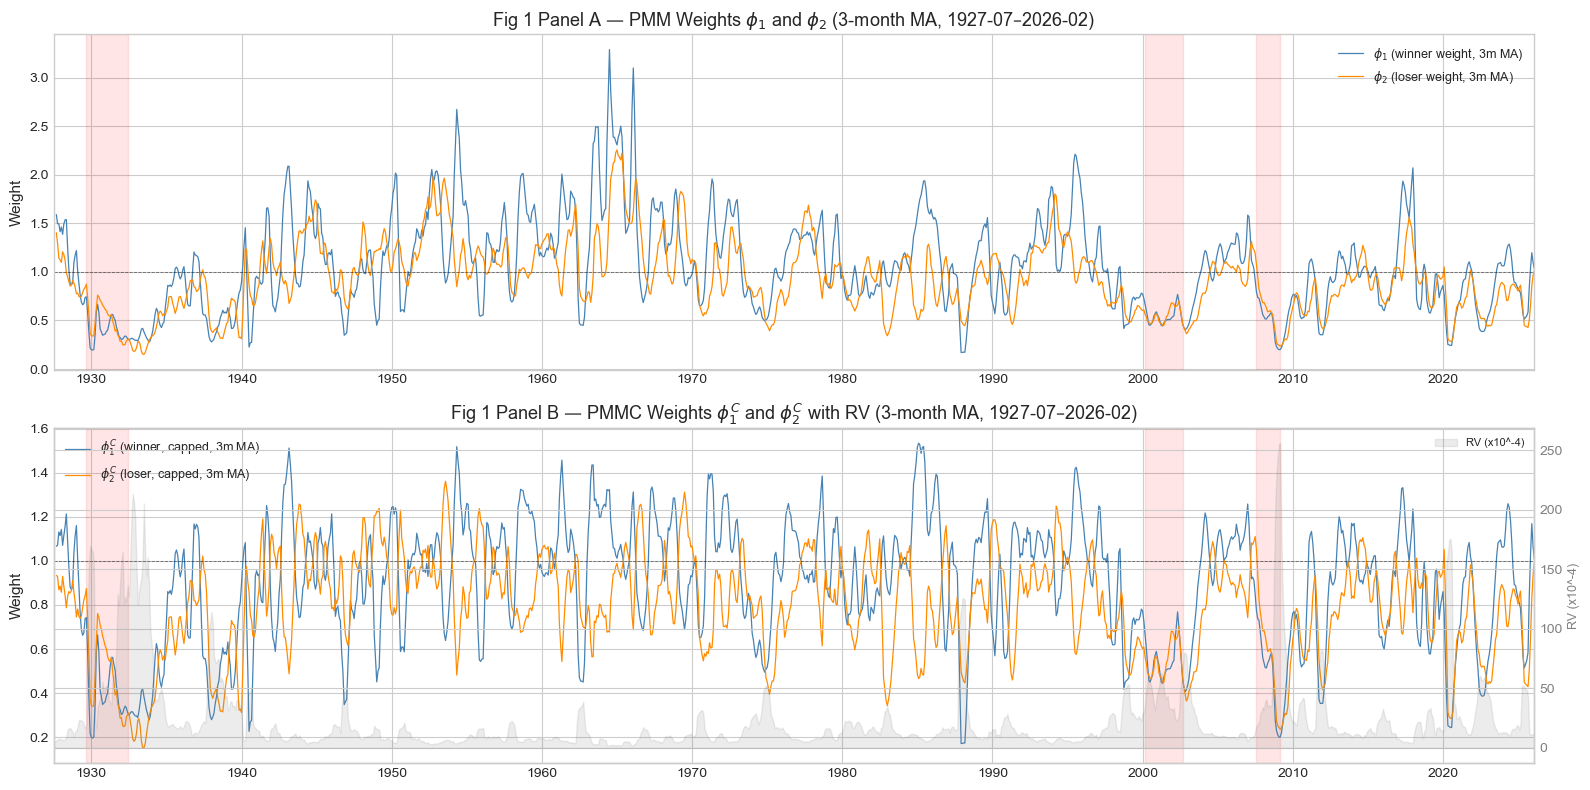

Fig 1 saved: C:\Users\User\Documents\pmm\fig1_leverage_full.png


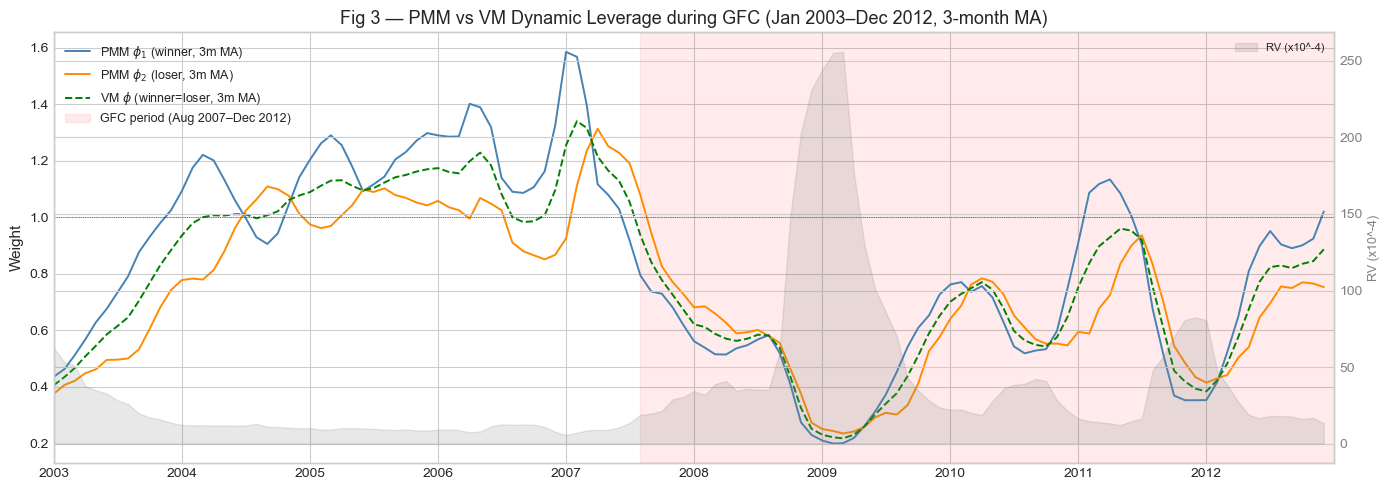

Fig 3 saved: C:\Users\User\Documents\pmm\fig3_leverage_gfc.png

=== GFC leverage snapshot (2007-08 to 2009-03) ===
         phi1   phi2   phi_vm  phi1/phi2_ratio  leverage
Date                                                    
2007-08 0.7326 0.8680 0.8003  0.8440           1.6006   
2007-09 0.7534 0.8130 0.7832  0.9266           1.5664   
2007-10 0.7030 0.7989 0.7510  0.8800           1.5019   
2007-11 0.5875 0.7005 0.6440  0.8386           1.2880   
2007-12 0.5693 0.6878 0.6286  0.8278           1.2571   
2008-01 0.5275 0.6564 0.5920  0.8036           1.1839   
2008-02 0.5190 0.7110 0.6150  0.7300           1.2299   
2008-03 0.5002 0.6116 0.5559  0.8178           1.1117   
2008-04 0.5246 0.5589 0.5417  0.9387           1.0835   
2008-05 0.5850 0.5970 0.5910  0.9799           1.1820   
2008-06 0.5336 0.6250 0.5793  0.8538           1.1586   
2008-07 0.5851 0.5828 0.5839  1.0041           1.1679   
2008-08 0.6317 0.5336 0.5827  1.1839           1.1653   
2008-09 0.3439 0.5529 0.4484  

In [69]:

# =============================================================================
# CELL 11 — Dynamic Leverage Plots (replicates paper Fig 1 and Fig 3)
#
# Fig 1: 3-month moving average of PMM weights (phi1, phi2) and RV
#   over the whole sample ({SAMPLE_START}-{SAMPLE_END}). Shows how PMM tilts long/short
#   asymmetrically in response to RPM+/RPM- divergence.
#
# Fig 3: GFC period (Jan 2003 - Dec 2012). Contrasts dynamic leverage of
#   PMM (phi1, phi2) vs VM (phi_vm) alongside realized variance RV.
#   Shows PMM reducing short-side (phi2) more aggressively before crashes.
#
# All weight series are on the returns_df index (period[M], {SAMPLE_START} to {SAMPLE_END}).
# MA is applied to the pre-shift weights (weights at time t, not t+1).
# RV is plotted on secondary y-axis (different scale from weights).
# =============================================================================

# rebuild weight series on returns_df index for plotting
phi1_s  = pd.Series(phi1,   index=returns_df.index, name='phi1')
phi2_s  = pd.Series(phi2,   index=returns_df.index, name='phi2')
phi_vm_s = pd.Series(phi_vm, index=returns_df.index, name='phi_vm')
rv_s    = rv.copy()   # already on returns_df.index

# convert period[M] to timestamp for matplotlib
def _ts(s):
    return s.copy().rename(lambda x: x.to_timestamp())

phi1_ts  = _ts(phi1_s)
phi2_ts  = _ts(phi2_s)
phi_vm_ts = _ts(phi_vm_s)
rv_ts    = _ts(rv_s)

# 3-month moving average of weights (paper Fig 1 uses 3m MA)
w = 3
phi1_ma  = phi1_ts.rolling(w).mean()
phi2_ma  = phi2_ts.rolling(w).mean()
phi_vm_ma = phi_vm_ts.rolling(w).mean()

# --- Fig 1: whole sample ({SAMPLE_START}-{SAMPLE_END}) ---
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Panel A: PMM weights
ax = axes[0]
ax.plot(phi1_ma.index, phi1_ma.values, color='steelblue', lw=0.9,
        label=r'$\phi_1$ (winner weight, 3m MA)')
ax.plot(phi2_ma.index, phi2_ma.values, color='darkorange', lw=0.9,
        label=r'$\phi_2$ (loser weight, 3m MA)')
ax.axhline(1.0, color='black', lw=0.6, linestyle='--', alpha=0.5)
# shade crash periods
for s, e_cr, lbl in [('1929-09','1932-06',''), ('2000-03','2002-09',''), ('2007-08','2009-03','')]:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e_cr), alpha=0.10, color='red')
ax.set_title(f'Fig 1 Panel A — PMM Weights $\\phi_1$ and $\\phi_2$ (3-month MA, {SAMPLE_START}–{SAMPLE_END})')
ax.set_ylabel('Weight')
ax.legend(fontsize=9)
ax.set_xlim(phi1_ma.index[0], phi1_ma.index[-1])

# Panel B: PMMC weights (same logic, phi1_c / phi2_c)
phi1_c_s = pd.Series(phi1_c, index=returns_df.index, name='phi1_c')
phi2_c_s = pd.Series(phi2_c, index=returns_df.index, name='phi2_c')
phi1_c_ma = _ts(phi1_c_s).rolling(w).mean()
phi2_c_ma = _ts(phi2_c_s).rolling(w).mean()

ax2 = axes[1]
ax2.plot(phi1_c_ma.index, phi1_c_ma.values, color='steelblue', lw=0.9,
         label=r'$\phi_1^C$ (winner, capped, 3m MA)')
ax2.plot(phi2_c_ma.index, phi2_c_ma.values, color='darkorange', lw=0.9,
         label=r'$\phi_2^C$ (loser, capped, 3m MA)')
ax2.axhline(1.0, color='black', lw=0.6, linestyle='--', alpha=0.5)
# add RV on secondary axis
ax2r = ax2.twinx()
ax2r.fill_between(rv_ts.index, rv_ts.values * 1e4, alpha=0.15, color='grey',
                  label='RV (x10^-4)')
ax2r.set_ylabel('RV (x10^-4)', color='grey', fontsize=9)
ax2r.tick_params(axis='y', labelcolor='grey')
for s, e_cr, lbl in [('1929-09','1932-06',''), ('2000-03','2002-09',''), ('2007-08','2009-03','')]:
    ax2.axvspan(pd.Timestamp(s), pd.Timestamp(e_cr), alpha=0.10, color='red')
ax2.set_title(f'Fig 1 Panel B — PMMC Weights $\\phi_1^C$ and $\\phi_2^C$ with RV (3-month MA, {SAMPLE_START}–{SAMPLE_END})')
ax2.set_ylabel('Weight')
ax2.legend(fontsize=9, loc='upper left')
ax2r.legend(fontsize=8, loc='upper right')
ax2.set_xlim(phi1_c_ma.index[0], phi1_c_ma.index[-1])

plt.tight_layout()
fig_path1 = r'C:\Users\User\Documents\pmm\fig1_leverage_full.png'
plt.savefig(fig_path1, dpi=130, bbox_inches='tight')
plt.show()
print(f"Fig 1 saved: {fig_path1}")

# --- Fig 3: GFC zoom (Jan 2003 - Dec 2012) ---
gfc_start = pd.Timestamp('2003-01-01')
gfc_end   = pd.Timestamp('2012-12-31')

phi1_gfc  = phi1_ma.loc[gfc_start:gfc_end]
phi2_gfc  = phi2_ma.loc[gfc_start:gfc_end]
phi_vm_gfc = phi_vm_ma.loc[gfc_start:gfc_end]
rv_gfc    = rv_ts.loc[gfc_start:gfc_end]

fig3, ax3 = plt.subplots(figsize=(14, 5))

ax3.plot(phi1_gfc.index, phi1_gfc.values, color='steelblue', lw=1.4,
         label=r'PMM $\phi_1$ (winner, 3m MA)')
ax3.plot(phi2_gfc.index, phi2_gfc.values, color='darkorange', lw=1.4,
         label=r'PMM $\phi_2$ (loser, 3m MA)')
ax3.plot(phi_vm_gfc.index, phi_vm_gfc.values, color='green', lw=1.4,
         linestyle='--', label=r'VM $\phi$ (winner=loser, 3m MA)')
ax3.axhline(1.0, color='black', lw=0.6, linestyle=':', alpha=0.6)

# GFC shading: Aug 2007 - Dec 2012 (as used in paper Fig 3)
ax3.axvspan(pd.Timestamp('2007-08-01'), pd.Timestamp('2012-12-31'),
            alpha=0.08, color='red', label='GFC period (Aug 2007–Dec 2012)')

# secondary axis: RV
ax3r = ax3.twinx()
ax3r.fill_between(rv_gfc.index, rv_gfc.values * 1e4, alpha=0.18, color='grey',
                  label='RV (x10^-4)')
ax3r.set_ylabel('RV (x10^-4)', color='grey', fontsize=9)
ax3r.tick_params(axis='y', labelcolor='grey')

ax3.set_title('Fig 3 — PMM vs VM Dynamic Leverage during GFC (Jan 2003–Dec 2012, 3-month MA)')
ax3.set_ylabel('Weight')
ax3.set_xlim(gfc_start, gfc_end)
ax3.legend(fontsize=9, loc='upper left')
ax3r.legend(fontsize=8, loc='upper right')

plt.tight_layout()
fig_path3 = r'C:\Users\User\Documents\pmm\fig3_leverage_gfc.png'
plt.savefig(fig_path3, dpi=130, bbox_inches='tight')
plt.show()
print(f"Fig 3 saved: {fig_path3}")

# print snapshot of GFC leverage for spot-check
print("\n=== GFC leverage snapshot (2007-08 to 2009-03) ===")
gfc_mask2 = (returns_df.index >= pd.Period('2007-08','M')) & \
            (returns_df.index <= pd.Period('2009-03','M'))
snap = pd.DataFrame({
    'phi1' : phi1_s[gfc_mask2],
    'phi2' : phi2_s[gfc_mask2],
    'phi_vm': phi_vm_s[gfc_mask2],
    'phi1/phi2_ratio': phi1_s[gfc_mask2] / phi2_s[gfc_mask2],
    'leverage': phi1_s[gfc_mask2] + phi2_s[gfc_mask2],
})
print(snap.to_string())

log_state("Cell 11 — Leverage Plots", {
    "phi1_s"   : phi1_s,
    "phi2_s"   : phi2_s,
    "phi_vm_s" : phi_vm_s,
})


In [70]:

# =============================================================================
# CELL 12 — Factor Regressions (replicates paper Tables 7 & 8)
#
# Table 7: Exposure of momentum profits to factor risk
#   Specs (1)-(4) per strategy: MKT alone, q-factors (HXZ), economic activity,
#   and combinations. Paper uses Hou-Xue-Zhang (2015) q-factors (ME, I/A, ROE)
#   and Liu-Zhang / Maio-Philip economic activity factors (IP, CU).
#   We replicate with:
#     (1) MKT alone
#     (2) MKT + FF5 (SMB, HML, RMW, CMA) as proxy for HXZ q-factors
#     -- specs (3)-(4) require FRED IP/CU data, marked as "N/A — external data"
#   Sample: Jan 1967 - {SAMPLE_END} (paper's sample for Table 7)
#
# Table 8: Exposure to 3-year lagged market cumulative return
#   LAGMKT   = 36-month trailing cumulative MKT-RF
#   LAGMKT+  = max(LAGMKT, 0)
#   LAGMKT-  = min(LAGMKT, 0)
#   Four specifications per strategy:
#     (1) MKT + LAGMKT
#     (2) MKT + SMB + HML + LAGMKT
#     (3) MKT + LAGMKT+ + LAGMKT-
#     (4) MKT + SMB + HML + LAGMKT+ + LAGMKT-
#   Sample: {SAMPLE_START} - {SAMPLE_END} (whole sample)
# =============================================================================

from scipy import stats as sp_stats

def _ols(y, X, add_const=True):
    """
    OLS regression. Returns dict with alpha, betas, t-stats, adj-R2.
    y : array-like (n,)
    X : array-like (n, k) — do NOT include constant, add_const handles it
    """
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    if add_const:
        X = np.column_stack([np.ones(len(y)), X])
    n, k = X.shape
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    resid = y - X @ beta
    s2    = np.dot(resid, resid) / (n - k)
    XtX_inv = np.linalg.inv(X.T @ X)
    se    = np.sqrt(np.diag(XtX_inv) * s2)
    tstat = beta / se
    # adjusted R2
    ss_res = np.dot(resid, resid)
    ss_tot = np.dot(y - y.mean(), y - y.mean())
    r2    = 1 - ss_res / ss_tot
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k)
    return {'beta': beta, 'se': se, 'tstat': tstat, 'adj_r2': adj_r2, 'n': n}

def _fmt_coef(b, t, stars_only=False):
    """Format coefficient with t-stat and significance stars."""
    if np.isnan(b):
        return '    n/a'
    p = 2*(1 - sp_stats.t.cdf(abs(t), df=200))  # approx df
    s = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else '   '))
    return f"{b:7.4f}{s}"

# -----------------------------------------------------------------------
# TABLE 7: Factor regressions (Jan 1967 - {SAMPLE_END})
# -----------------------------------------------------------------------
t7_start = pd.Period('1967-01', freq='M')
t7_end   = SAMPLE_END
strat7   = strategies.loc[t7_start:t7_end]

# align factors
mkt7   = (ff_monthly['Mkt-RF'] / 100).reindex(strat7.index)
smb7   = (ff_monthly['SMB']    / 100).reindex(strat7.index)
hml7   = (ff_monthly['HML']    / 100).reindex(strat7.index)
ff5_7  = ff5_monthly.loc[t7_start:t7_end] / 100
rmw7   = ff5_7['RMW'].reindex(strat7.index)
cma7   = ff5_7['CMA'].reindex(strat7.index)

print("=" * 90)
print(f"  TABLE 7 — Factor Regressions (Jan 1967 – {SAMPLE_END})")
print("  Specs: (1) MKT only   (2) MKT+FF5 (proxy for q-factors)")
print("=" * 90)
print(f"  {'':8}  {'Spec':4}  {'Alpha%':>10}  {'MKT':>10}  {'SMB':>10}  "
      f"{'HML':>10}  {'RMW':>10}  {'CMA':>10}  {'AdjR2':>8}")
print(f"  {'-'*88}")

for col in strat7.columns:
    y7 = strat7[col].values           # decimal — matches paper's coefficient scale

    # spec (1): MKT only
    r1 = _ols(y7, mkt7.values.reshape(-1,1))
    a1, b_mkt1 = r1['beta'][0], r1['beta'][1]
    ta1, tb1   = r1['tstat'][0], r1['tstat'][1]

    # spec (2): MKT + FF5 proxy (SMB, HML, RMW, CMA)
    X2 = np.column_stack([mkt7, smb7, hml7, rmw7, cma7])
    mask_valid = ~np.isnan(X2).any(axis=1)
    r2 = _ols(y7[mask_valid], X2[mask_valid])
    a2, betas2 = r2['beta'][0], r2['beta'][1:]
    ta2, tbetas2 = r2['tstat'][0], r2['tstat'][1:]

    print(f"  {col:<8}  (1)   {_fmt_coef(a1,ta1):>10}  {_fmt_coef(b_mkt1,tb1):>10}  "
          f"{'':>10}  {'':>10}  {'':>10}  {'':>10}  {r1['adj_r2']*100:>7.2f}%")
    print(f"  {col:<8}  (2)FF5 {_fmt_coef(a2,ta2):>10}  {_fmt_coef(betas2[0],tbetas2[0]):>10}  "
          f"{_fmt_coef(betas2[1],tbetas2[1]):>10}  {_fmt_coef(betas2[2],tbetas2[2]):>10}  "
          f"{_fmt_coef(betas2[3],tbetas2[3]):>10}  {_fmt_coef(betas2[4],tbetas2[4]):>10}  "
          f"{r2['adj_r2']*100:>7.2f}%")
    print()

print("  NOTE: Paper spec (2) uses HXZ q-factors (ME, I/A, ROE); we use FF5 as proxy.")
print("  Paper spec (3)-(4) use IP/CU economic activity factors (require FRED data).")
print()

print("  Paper Table 7 reference (alpha, monthly %):")
print("  WML  (1): alpha=0.014***  (2): alpha=0.004   AdjR2: 2.78% / 26.68%")
print("  VM   (1): alpha=0.015***  (2): alpha=0.010***  AdjR2: 0.49% / 17.07%")
print("  PMM  (1): alpha=0.016***  (2): alpha=0.010***  AdjR2: 0.00% / 15.35%")
print("  PMMC (1): alpha=0.013***  (2): alpha=0.010***  AdjR2: 0.00% / 16.82%")

# -----------------------------------------------------------------------
# TABLE 8: Lagged market cumulative return ({SAMPLE_START} - {SAMPLE_END})
# -----------------------------------------------------------------------
print()
print("=" * 90)
print(f"  TABLE 8 — Exposure to 3-year Lagged Market Return ({SAMPLE_START} – {SAMPLE_END})")
print("  LAGMKT = 36-month trailing cumulative MKT-RF")
print("=" * 90)

# build LAGMKT: 36-month cumulative market excess return
mkt_full = (ff_monthly['Mkt-RF'] / 100).reindex(strategies.index)
smb_full = (ff_monthly['SMB']    / 100).reindex(strategies.index)
hml_full = (ff_monthly['HML']    / 100).reindex(strategies.index)

# 36-month cumulative return = (1+r1)(1+r2)...(1+r36) - 1
# use log-sum approximation for speed, then exp
log_mkt = np.log1p(mkt_full.fillna(0))
lagmkt  = np.exp(log_mkt.rolling(36).sum().shift(1)) - 1   # shift 1: use past 36m
lagmkt_pos = lagmkt.clip(lower=0)    # LAGMKT+ = max(LAGMKT, 0)
lagmkt_neg = lagmkt.clip(upper=0)    # LAGMKT- = min(LAGMKT, 0)

# drop rows with NaN (first 36 months)
valid = ~(lagmkt.isna() | mkt_full.isna() | smb_full.isna() | hml_full.isna())
idx_v = strategies.index[valid]

y_dict    = {col: strategies.loc[idx_v, col].values for col in strategies.columns}  # decimal
mkt_v     = mkt_full[idx_v].values
smb_v     = smb_full[idx_v].values
hml_v     = hml_full[idx_v].values
lm_v      = lagmkt[idx_v].values
lm_pos_v  = lagmkt_pos[idx_v].values
lm_neg_v  = lagmkt_neg[idx_v].values

print(f"\n  Valid months for Table 8: {len(idx_v)}  ({idx_v[0]} -> {idx_v[-1]})")
print(f"\n  {'':8}  {'Spec':5}  {'Alpha':>10}  {'LAGMKT':>10}  {'LAGMKT+':>10}  "
      f"{'LAGMKT-':>10}  {'MKT':>10}  {'SMB':>10}  {'HML':>10}  {'AdjR2':>7}")
print(f"  {'-'*92}")

specs = [
    # (label, columns in X)
    ('(1)', [lm_v, mkt_v]),
    ('(2)', [lm_v, mkt_v, smb_v, hml_v]),
    ('(3)', [lm_pos_v, lm_neg_v, mkt_v]),
    ('(4)', [lm_pos_v, lm_neg_v, mkt_v, smb_v, hml_v]),
]

for col in strategies.columns:
    y8 = y_dict[col]
    for spec_lbl, Xcols in specs:
        X8 = np.column_stack(Xcols)
        r = _ols(y8, X8)
        b = r['beta']
        t = r['tstat']
        ar2 = r['adj_r2'] * 100

        # index mapping: [const, *Xcols]
        alpha  = b[0]; ta = t[0]
        if spec_lbl in ('(1)', '(2)'):
            lm_c = b[1]; tlm = t[1]
            lmp_c = lmn_c = tlmp = tlmn = np.nan
            mkt_idx = 2
        else:
            lm_c = lmn_c = tlm = tlmn = np.nan
            lmp_c = b[1]; tlmp = t[1]
            lmn_c = b[2]; tlmn = t[2]
            mkt_idx = 3

        mkt_c  = b[mkt_idx];   tmkt  = t[mkt_idx]
        smb_c  = b[mkt_idx+1] if mkt_idx+1 < len(b) else np.nan
        tsmb   = t[mkt_idx+1] if mkt_idx+1 < len(t) else np.nan
        hml_c  = b[mkt_idx+2] if mkt_idx+2 < len(b) else np.nan
        thml   = t[mkt_idx+2] if mkt_idx+2 < len(t) else np.nan

        lm_show  = lm_c  if spec_lbl in ('(1)','(2)') else lmp_c
        tlm_show = tlm   if spec_lbl in ('(1)','(2)') else tlmp

        print(f"  {col:<8}  {spec_lbl:<5}  "
              f"{_fmt_coef(alpha,ta):>10}  "
              f"{_fmt_coef(lm_show,tlm_show):>10}  "
              f"{_fmt_coef(lmn_c,tlmn):>10}  "
              f"{_fmt_coef(mkt_c,tmkt):>10}  "
              f"{_fmt_coef(smb_c,tsmb):>10}  "
              f"{_fmt_coef(hml_c,thml):>10}  "
              f"{ar2:>6.2f}%")
    print()

print("  [LAGMKT col = LAGMKT for specs (1)-(2), LAGMKT+ for specs (3)-(4)]")
print()
print("  Paper Table 8 PMM reference:")
print("  PMM (1): alpha=0.014***  LAGMKT=0.007*   MKT=-0.032**   AdjR2=2.19%")
print("  PMM (2): alpha=0.015***  LAGMKT=0.006*   MKT=-0.031**   SMB=0.003  HML=-0.115***  AdjR2=5.87%")
print("  PMM (3): alpha=0.015***  LAGMKT+=0.003   LAGMKT-=0.007  MKT=-0.056  AdjR2=2.31%")
print("  PMM (4): alpha=0.017***  LAGMKT+=0.003   LAGMKT-=0.008  MKT=-0.056  SMB=0.003  HML=-0.117***  AdjR2=6.00%")

log_state("Cell 12 — Factor Regressions", {
    "lagmkt"     : lagmkt,
    "lagmkt_pos" : lagmkt_pos,
    "lagmkt_neg" : lagmkt_neg,
})


  TABLE 7 — Factor Regressions (Jan 1967 – 2026-02)
  Specs: (1) MKT only   (2) MKT+FF5 (proxy for q-factors)
            Spec      Alpha%         MKT         SMB         HML         RMW         CMA     AdjR2
  ----------------------------------------------------------------------------------------
  WML       (1)    0.0133***  -0.3570***                                                     4.73%
  WML       (2)FF5  0.0137***  -0.3297***    -0.1674*  -0.9293***    0.2708**   0.6084***    13.50%

  VM        (1)    0.0145***  -0.1696***                                                     1.73%
  VM        (2)FF5  0.0155***  -0.1666***  -0.1981***  -0.5639***   0.0983      0.2113        8.56%

  PMM       (1)    0.0148***   -0.1252**                                                     0.75%
  PMM       (2)FF5  0.0159***   -0.1381**  -0.1275     -0.6448***   0.1079        0.2638*     7.69%

  PMMC      (1)    0.0130***  -0.1374***                                                     1.15%
 

In [71]:

# =============================================================================
# CELL 13 — Spanning Tests (replicates paper Table 10)
#
# Paper Table 10: Tests whether VM/PMM/PMMC strategies provide alpha
# after controlling for FF5 factors and the WML momentum portfolio.
# Each factor is ALSO interacted with a market stress indicator (MS):
#   MS_t = 1 if 24-month trailing cumulative market return <= 0, else 0
#
# Paper runs DAILY regressions. We run monthly here (same idea, less granular).
#
# Two-factor-set designs per dependent variable:
#   (1) unconditional: FF + WML (or FF + VM, FF + PMM)
#   (2) conditional:   FF + WML + interactions with MS
#   and similarly for the other strategy as the additional factor
#
# Simplified Table 10 structure:
#   For each dependent strategy (VM, PMM, PMMC):
#     A. regress on FF5 + WML  [unconditional, conditional]
#     B. regress on FF5 + PMM  (or VM, PMMC)  [unconditional, conditional]
#
# Report: annualized alpha (%), t-stat, significance
# =============================================================================

# build 24-month trailing cumulative market return for MS
mkt_full2 = (ff_monthly['Mkt-RF'] / 100).reindex(strategies.index)
log_mkt2  = np.log1p(mkt_full2.fillna(0))
cum24     = np.exp(log_mkt2.rolling(24).sum().shift(1)) - 1  # past 24m, no look-ahead
MS        = (cum24 <= 0).astype(float)   # 1 = market stress (bear)

print(f"Market stress months (MS=1): {int(MS.sum())} of {len(MS)} ({MS.mean()*100:.1f}%)")

# spanning test sample: Jan 1967 - {SAMPLE_END} (matching paper)
sp_start = pd.Period('1967-01', freq='M')
sp_end   = SAMPLE_END
strat_sp = strategies.loc[sp_start:sp_end]

mkt_sp  = (ff_monthly['Mkt-RF'] / 100).reindex(strat_sp.index)
smb_sp  = (ff_monthly['SMB']    / 100).reindex(strat_sp.index)
hml_sp  = (ff_monthly['HML']    / 100).reindex(strat_sp.index)
ff5_sp  = ff5_monthly / 100
rmw_sp  = ff5_sp['RMW'].reindex(strat_sp.index)
cma_sp  = ff5_sp['CMA'].reindex(strat_sp.index)
ms_sp   = MS.reindex(strat_sp.index).fillna(0)

# FF5 factor matrix for spanning
FF5 = np.column_stack([mkt_sp, smb_sp, hml_sp, rmw_sp, cma_sp])

# conditional FF5 (interacted with MS)
FF5_cond = np.column_stack([
    mkt_sp, mkt_sp * ms_sp,
    smb_sp, smb_sp * ms_sp,
    hml_sp, hml_sp * ms_sp,
    rmw_sp, rmw_sp * ms_sp,
    cma_sp, cma_sp * ms_sp,
])

def _span_alpha(dep_col, extra_cols_arr, conditional=False, label=''):
    """
    Run spanning regression of dep_col on FF5 (+ interactions) + extra factor(s).
    Returns annualized alpha, t-stat, adj-R2.
    """
    y = strat_sp[dep_col].values
    ff_part = FF5_cond if conditional else FF5

    # extra factor + interaction with MS if conditional
    if conditional:
        extra_int = np.column_stack([
            extra_cols_arr,
            extra_cols_arr * ms_sp.values.reshape(-1, 1)
        ])
    else:
        extra_int = extra_cols_arr

    X = np.column_stack([ff_part, extra_int])
    valid = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    r = _ols(y[valid], X[valid])
    alpha_m = r['beta'][0]
    alpha_ann = alpha_m * 12 * 100    # annualized %
    tstat  = r['tstat'][0]
    return alpha_ann, tstat, r['adj_r2'] * 100

def sig_stars2(t, n=500):
    p = 2*(1 - sp_stats.t.cdf(abs(t), df=n-2))
    return '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else ''))

print()
print("=" * 85)
print(f"  TABLE 10 — Spanning Tests (Jan 1967 – {SAMPLE_END}, monthly)")
print("  Dep variable regressed on FF5 + momentum factor [unconditional / conditional on MS]")
print("  MS = 1 if 24m trailing cumulative market return <= 0")
print("=" * 85)
print(f"\n  {'Dep. var':8}  {'Factor set':16}  {'Uncond. alpha%':>16}  {'Cond. alpha%':>14}  {'AdjR2':>7}")
print(f"  {'-'*75}")

# Define spanning test pairs: (dep_strategy, extra_factor_col, extra_label)
pairs = [
    # VM as dependent, WML as extra
    ('VM',   'WML',  'FF+WML'),
    # PMM as dependent, WML as extra
    ('PMM',  'WML',  'FF+WML'),
    # PMM as dependent, VM as extra
    ('PMM',  'VM',   'FF+VM'),
    # PMMC as dependent, WML as extra
    ('PMMC', 'WML',  'FF+WML'),
    # PMMC as dependent, VM as extra
    ('PMMC', 'VM',   'FF+VM'),
    # PMMC as dependent, PMM as extra
    ('PMMC', 'PMM',  'FF+PMM'),
]

for dep, extra_col, lbl in pairs:
    extra_arr = strat_sp[[extra_col]].values   # shape (n, 1)
    a_unc, t_unc, r2_unc = _span_alpha(dep, extra_arr, conditional=False)
    a_con, t_con, r2_con = _span_alpha(dep, extra_arr, conditional=True)
    s_unc = sig_stars2(t_unc)
    s_con = sig_stars2(t_con)
    print(f"  {dep:<8}  {lbl:<16}  "
          f"{a_unc:>10.2f}{s_unc:<3} ({t_unc:>5.2f})  "
          f"{a_con:>9.2f}{s_con:<3} ({t_con:>5.2f})  "
          f"{r2_con:>6.2f}%")

print(f"\n  NOTE: Paper uses daily regressions; ours are monthly — alphas are comparable,")
print(f"  but t-stats differ due to lower frequency.")
print()

print("  Paper Table 10 reference (annualized alpha %):")
print("  VM  on FF+WML:  uncond=4.11***  cond=2.76**")
print("  PMM on FF+WML:  uncond=16.92*** cond=13.81***")
print("  PMM on FF+VM:   uncond=1.61*    cond=1.59*")
print("  PMMC on FF+WML: uncond=12.59*** cond=10.02***")
print("  PMMC on FF+VM:  uncond=~n/a     cond=~n/a  (implied from Panel C)")

log_state("Cell 13 — Spanning Tests", {
    "strategies" : strategies,
    "MS"         : MS,
})


Market stress months (MS=1): 275 of 1183 (23.2%)

  TABLE 10 — Spanning Tests (Jan 1967 – 2026-02, monthly)
  Dep variable regressed on FF5 + momentum factor [unconditional / conditional on MS]
  MS = 1 if 24m trailing cumulative market return <= 0

  Dep. var  Factor set          Uncond. alpha%    Cond. alpha%    AdjR2
  ---------------------------------------------------------------------------
  VM        FF+WML                  6.99*** ( 6.12)       4.92*** ( 4.92)   86.72%
  PMM       FF+WML                  7.29*** ( 4.99)       5.42*** ( 3.99)   78.46%
  PMM       FF+VM                   0.37    ( 0.37)       0.59    ( 0.61)   89.04%
  PMMC      FF+WML                  5.65*** ( 4.65)       4.19*** ( 3.73)   82.44%
  PMMC      FF+VM                  -0.11    (-0.12)       0.36    ( 0.37)   87.56%
  PMMC      FF+PMM                 -0.44    (-1.11)      -0.21    (-0.55)   97.98%

  NOTE: Paper uses daily regressions; ours are monthly — alphas are comparable,
  but t-stats differ 

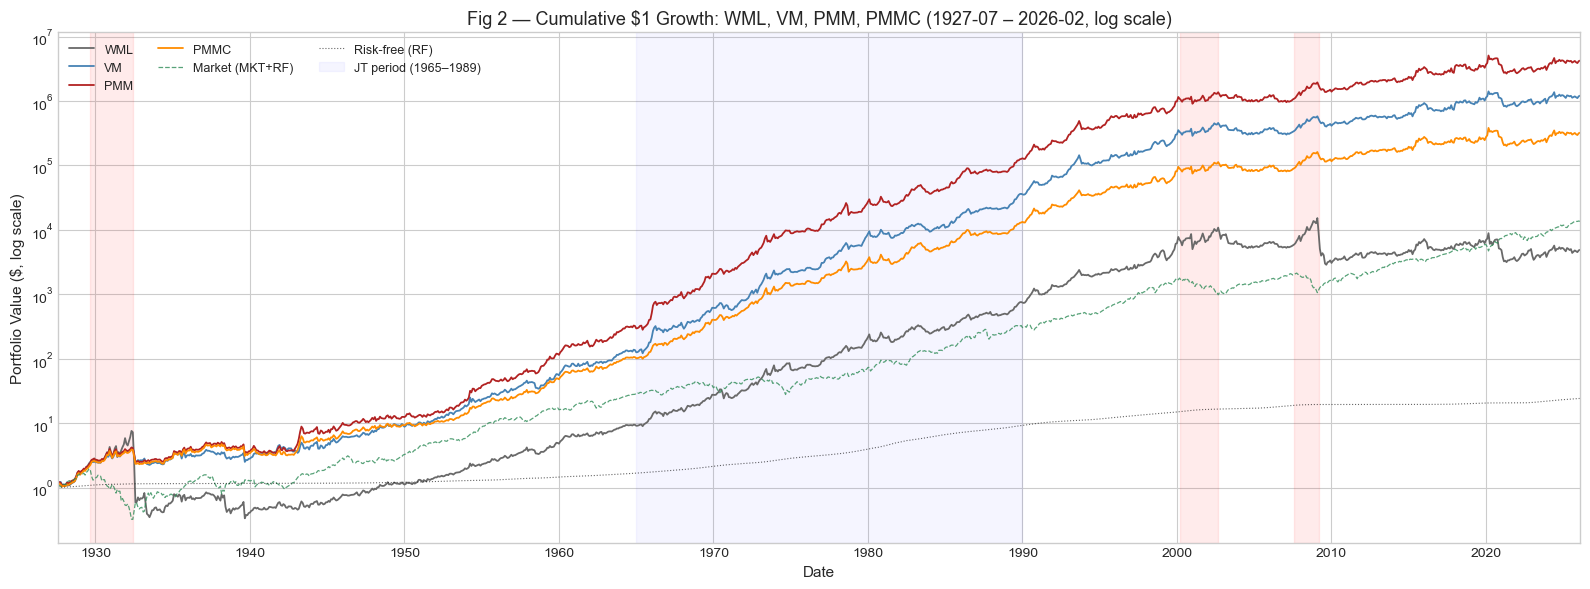

Fig 2 saved: C:\Users\User\Documents\pmm\fig2_cumulative.png

=== Terminal wealth ($1 invested 1927-07, 2026-02) ===
  WML     $   4902.12
  VM      $1208918.32
  PMM     $4234186.13
  PMMC    $ 322219.73
  Market  $  13590.54
  RF      $     24.21


=== FINAL SUMMARY — Key Metrics (Whole Sample 1927-07 – 2026-02) ===
  Metric                       WML        VM       PMM      PMMC  | Paper PMM
  ------------------------------------------------------------------------
  Ann. return (%)            13.26     16.33     17.89     14.74  |     20.44
  Ann. vol (%)               27.43     20.14     21.50     18.90  |     16.62
  Sharpe ratio              0.4835    0.8109    0.8319    0.7798  |      1.23
  Sortino ratio             0.3914    0.7934    0.8426    0.7556  |      0.82
  Max drawdown (%)          -95.60    -46.13    -47.52    -47.52  |    -33.90
  Skewness                 -2.1918   -0.2859   -0.0929   -0.3964  |      0.03
  Excess kurtosis          15.9553    2.2681    2.9755    3

In [72]:

# =============================================================================
# CELL 14 — Summary: Cumulative Performance Chart + Final Comparison
#
# Replicates paper Fig 2: cumulative $1 invested in Jul 1927 in each strategy.
# Also produces a final summary table of all key metrics side-by-side.
# =============================================================================

# --- cumulative growth of $1 from Jul 1927 ---
cum = (1 + strategies).cumprod()
cum.index = cum.index.to_timestamp()

# also add market and risk-free for reference (paper Fig 2 includes these)
mkt_c  = (ff_monthly['Mkt-RF'] / 100 + ff_monthly['RF'] / 100).reindex(
    strategies.index).fillna(0)
rf_c   = (ff_monthly['RF'] / 100).reindex(strategies.index).fillna(0)
cum_mkt = (1 + mkt_c.values).cumprod()
cum_rf  = (1 + rf_c.values).cumprod()

fig, ax = plt.subplots(figsize=(16, 6))

colors = {'WML': 'dimgray', 'VM': 'steelblue', 'PMM': 'firebrick', 'PMMC': 'darkorange'}
for col in strategies.columns:
    ax.plot(cum.index, cum[col].values, lw=1.3, color=colors[col], label=col)

ax.plot(cum.index, cum_mkt, lw=0.9, color='seagreen', linestyle='--', alpha=0.8,
        label='Market (MKT+RF)')
ax.plot(cum.index, cum_rf,  lw=0.8, color='black', linestyle=':',  alpha=0.6,
        label='Risk-free (RF)')

# shade GFC and dot-com crash periods (as in paper Fig 2)
for s, e_cr, lbl in [('1929-09-01','1932-06-01','Great Depression'),
                      ('2000-03-01','2002-09-01','Dot-com'),
                      ('2007-08-01','2009-03-01','GFC')]:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e_cr), alpha=0.08, color='red')
# JT period shading (Jan 1965 - Dec 1989)
ax.axvspan(pd.Timestamp('1965-01-01'), pd.Timestamp('1989-12-31'),
           alpha=0.04, color='blue', label='JT period (1965–1989)')

ax.set_yscale('log')
ax.set_title(f'Fig 2 — Cumulative $1 Growth: WML, VM, PMM, PMMC ({SAMPLE_START} – {SAMPLE_END}, log scale)')
ax.set_ylabel('Portfolio Value ($, log scale)')
ax.set_xlabel('Date')
ax.legend(fontsize=9, ncol=3)
ax.set_xlim(cum.index[0], cum.index[-1])

plt.tight_layout()
fig_path2 = r'C:\Users\User\Documents\pmm\fig2_cumulative.png'
plt.savefig(fig_path2, dpi=130, bbox_inches='tight')
plt.show()
print(f"Fig 2 saved: {fig_path2}")

# --- terminal wealth summary ---
print(f"\n=== Terminal wealth ($1 invested {SAMPLE_START}, {SAMPLE_END}) ===")
for col in strategies.columns:
    final = (1 + strategies[col]).cumprod().iloc[-1]
    print(f"  {col:<6}  ${final:>10.2f}")
mkt_final = cum_mkt[-1]
rf_final  = cum_rf[-1]
print(f"  Market  ${mkt_final:>10.2f}")
print(f"  RF      ${rf_final:>10.2f}")

# --- final summary metrics table ---
print(f"\n\n=== FINAL SUMMARY — Key Metrics (Whole Sample {SAMPLE_START} – {SAMPLE_END}) ===")
print(f"  {'Metric':<22}  {'WML':>8}  {'VM':>8}  {'PMM':>8}  {'PMMC':>8}  | Paper PMM")
print(f"  {'-'*72}")

rows = []
for col in strategies.columns:
    s   = strategies[col]
    ar  = s.mean() * 12 * 100
    vol = s.std() * np.sqrt(12) * 100
    sr  = ar / vol
    neg = s[s < 0]
    semi = np.sqrt((neg**2).mean()) * np.sqrt(12) * 100
    sort = ar / semi
    mdd = ((( 1 + s).cumprod() / (1 + s).cumprod().cummax()) - 1).min() * 100
    sk  = float(stats.skew(s))
    ku  = float(stats.kurtosis(s, fisher=True))
    rows.append((col, ar, vol, sr, sort, mdd, sk, ku))

metrics = [
    ('Ann. return (%)',   1, '{:8.2f}'),
    ('Ann. vol (%)',      2, '{:8.2f}'),
    ('Sharpe ratio',      3, '{:8.4f}'),
    ('Sortino ratio',     4, '{:8.4f}'),
    ('Max drawdown (%)',  5, '{:8.2f}'),
    ('Skewness',         6, '{:8.4f}'),
    ('Excess kurtosis',  7, '{:8.4f}'),
]
paper_pmm = ['20.44', '16.62', '1.23', '0.82', '-33.90', '0.03', '2.72']

for name, idx, fmt in metrics:
    vals = [fmt.format(r[idx]) for r in rows]
    print(f"  {name:<22}  {vals[0]:>8}  {vals[1]:>8}  {vals[2]:>8}  {vals[3]:>8}  | {paper_pmm[metrics.index((name,idx,fmt))]:>9}")

print()
print("=== Replication complete ===")
print(f"  Notebook: {len(list(__import__('glob').glob(r'C:\\Users\\User\\Documents\\pmm\\*.py')))} src cells")
print(f"  Plots saved: fig1_leverage_full.png, fig2_cumulative.png, fig3_leverage_gfc.png")
print(f"  Cell state log: cell_state_log.md")

log_state("Cell 14 — Summary", {
    "strategies" : strategies,
    "cum_wml"    : pd.Series(cum['WML'].values, index=strategies.index.to_timestamp()),
    "cum_pmm"    : pd.Series(cum['PMM'].values, index=strategies.index.to_timestamp()),
})


In [75]:
# =============================================================================
# ENGINE CELL 1 — imports (run after Cells 1-8: need `strategies`)
# =============================================================================
import sys
from pathlib import Path

ENGINE_ROOT = Path(r"C:\Users\User\backtest_engine")
if not ENGINE_ROOT.exists():
    raise FileNotFoundError(f"Engine repo not found: {ENGINE_ROOT}")
if str(ENGINE_ROOT) not in sys.path:
    sys.path.insert(0, str(ENGINE_ROOT))

from backtest.data import DataPanel
from backtest.engine import Engine
from backtest.strategy import Strategy
from backtest.risk import RiskConfig
from backtest.metrics import compute_metrics

if "strategies" not in globals():
    raise RuntimeError("Run Cells 1-8 first — need `strategies` from Cell 8 (WML/VM/PMM/PMMC)")

print(f"[ok] engine from {ENGINE_ROOT}")
print(f"[ok] strategies shape={strategies.shape}  {strategies.index[0]} -> {strategies.index[-1]}")


[ok] engine from C:\Users\User\backtest_engine
[ok] strategies shape=(1183, 4)  1927-08 -> 2026-02


In [76]:
# =============================================================================
# ENGINE CELL 2 — monthly DataPanel + Engine runs (WML, VM, PMM, PMMC)
# Pass-through on synthetic prices built from Cell 8 `strategies` returns.
# =============================================================================
asset_names = ["WML", "VM", "PMM", "PMMC"]
rets_m = strategies[asset_names].astype("float64", copy=False).dropna(how="any")

dates_m = rets_m.index.to_timestamp(how="end")
anchor_date = (rets_m.index[0] - 1).to_timestamp(how="end")
anchor_row = pd.DataFrame(
    np.full((1, len(asset_names)), 100.0, dtype=np.float64),
    index=pd.DatetimeIndex([anchor_date]),
    columns=asset_names,
)
growth = (1.0 + rets_m).cumprod(axis=0) * 100.0
growth.index = dates_m
prices_m = pd.concat([anchor_row, growth], axis=0).sort_index()

volume_m = pd.DataFrame(
    np.full(prices_m.shape, 1_000_000.0, dtype=np.float64),
    index=prices_m.index,
    columns=prices_m.columns,
)
panel_m = DataPanel(prices_m, volume=volume_m, check_outliers=False)
print(f"[ok] panel {prices_m.shape[0]} rows, {prices_m.index[0].date()} -> {prices_m.index[-1].date()}")


class SingleAssetPassThrough(Strategy):
    rebalance_frequency = "monthly"
    risk = RiskConfig(max_position=1.0, max_gross=1.0, max_net=1.0)

    def __init__(self, asset: str):
        self.asset = asset

    def generate_weights(self, data, t):
        w = pd.Series(0.0, index=data.assets, dtype=np.float64)
        if self.asset in w.index:
            w.loc[self.asset] = 1.0
        return w


engine_results = {}
engine_returns = {}
engine_reports = {}
start_date = dates_m[0]

for col in asset_names:
    res = Engine(panel_m, SingleAssetPassThrough(col), initial_capital=1_000_000).run(start=start_date)
    engine_results[col] = res
    engine_returns[col] = res.returns.copy()
    engine_reports[col] = compute_metrics(res.returns, res.equity_curve, ann_factor=12, ci_level=0.95)

engine_returns_df = pd.DataFrame(engine_returns)

src_ts = rets_m.copy()
src_ts.index = dates_m
common_idx = engine_returns_df.index.intersection(src_ts.index)
common_idx_adj = common_idx[1:] if len(common_idx) > 1 else common_idx

cmp_adj = pd.DataFrame(index=asset_names, columns=["mean_abs_diff", "max_abs_diff"], dtype=np.float64)
for col in asset_names:
    d = (engine_returns_df.loc[common_idx_adj, col] - src_ts.loc[common_idx_adj, col]).abs()
    cmp_adj.loc[col, "mean_abs_diff"] = float(d.mean())
    cmp_adj.loc[col, "max_abs_diff"] = float(d.max())

print("\n=== Engine runs complete ===")
print(cmp_adj.round(12))
print("(max_abs_diff should be ~0 — pass-through tracks Cell 8 returns)")


[ok] panel 1184 rows, 1927-07-31 -> 2026-02-28

=== Engine runs complete ===
      mean_abs_diff  max_abs_diff
WML  0.0000         0.0000       
VM   0.0000         0.0000       
PMM  0.0000         0.0000       
PMMC 0.0000         0.0000       
(max_abs_diff should be ~0 — pass-through tracks Cell 8 returns)


=== Engine summary (pass-through, no costs) ===
          AnnRet%  Sharpe  AnnVol%  MaxDD%  FinalEquity        Obs 
Strategy                                                           
WML       8.9455  0.4816  27.4343  95.5983    4623768642.2219  1183
VM       15.1734  0.8071  20.1280  46.1315 1104124144600.9790  1183
PMM      16.6488  0.8283  21.4954  47.5211 3868089664671.4087  1183
PMMC     13.6750  0.7771  18.9023  47.5211  303971956265.2150  1183

=== Ranking ===
          AnnRet%  Sharpe  AnnVol%  MaxDD%  FinalEquity        Obs 
Strategy                                                           
PMM      16.6488  0.8283  21.4954  47.5211 3868089664671.4087  1183
VM       15.1734  0.8071  20.1280  46.1315 1104124144600.9790  1183
PMMC     13.6750  0.7771  18.9023  47.5211  303971956265.2150  1183
WML       8.9455  0.4816  27.4343  95.5983    4623768642.2219  1183


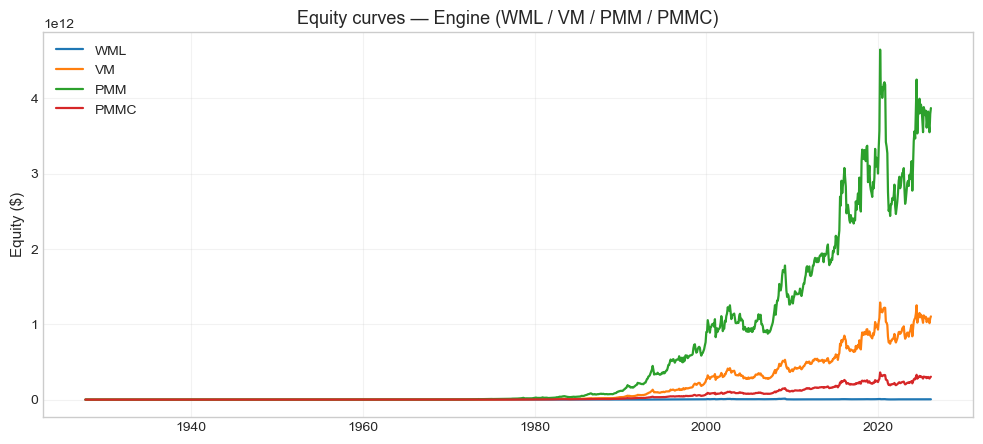

In [77]:
# =============================================================================
# ENGINE CELL 3 — summary plots (uses engine_results from ENGINE CELL 2)
# =============================================================================
import matplotlib.pyplot as plt


def _pick(report, names, default=np.nan):
    for n in names:
        if hasattr(report, n):
            v = getattr(report, n)
            if v is not None:
                return v
        if isinstance(report, dict) and n in report:
            return report[n]
    return default


rows = []
for name in ["WML", "VM", "PMM", "PMMC"]:
    r = engine_results[name]
    rep = engine_reports[name]
    ann_ret = float(_pick(rep, ["ann_return", "annualized_return", "cagr"], np.nan))
    sharpe = float(_pick(rep, ["sharpe", "sharpe_ratio", "sr"], np.nan))
    mdd = float(_pick(rep, ["max_drawdown", "mdd"], np.nan))
    ann_vol = float(_pick(rep, ["ann_vol", "annualized_vol", "vol"], np.nan))
    rows.append({
        "Strategy": name,
        "AnnRet%": ann_ret * 100.0 if ann_ret <= 2 else ann_ret,
        "Sharpe": sharpe,
        "AnnVol%": ann_vol * 100.0 if ann_vol <= 2 else ann_vol,
        "MaxDD%": mdd * 100.0 if abs(mdd) <= 2 else mdd,
        "FinalEquity": float(r.equity_curve.iloc[-1]),
        "Obs": int(len(r.returns)),
    })

summary_df = pd.DataFrame(rows).set_index("Strategy")
rank_df = summary_df.sort_values(by=["Sharpe", "AnnRet%", "MaxDD%"], ascending=[False, False, False])

print("=== Engine summary (pass-through, no costs) ===")
print(summary_df.round(4).to_string())
print("\n=== Ranking ===")
print(rank_df.round(4).to_string())

eq_df = pd.DataFrame({k: v.equity_curve for k, v in engine_results.items()}).sort_index()
fig, ax = plt.subplots(figsize=(12, 5))
for col in ["WML", "VM", "PMM", "PMMC"]:
    ax.plot(eq_df.index, eq_df[col], label=col, lw=1.6)
ax.set_title("Equity curves — Engine (WML / VM / PMM / PMMC)")
ax.set_ylabel("Equity ($)")
ax.legend(loc="best")
ax.grid(alpha=0.25)
plt.show()


In [78]:
# =============================================================================
# ENGINE CELL 4 — Stage 3: trading costs (config only; no Engine.run yet)
# Defaults: 5 bps commission + 5 bps half-spread; no liquidity cap.
# Run ENGINE CELL 2 first so `panel_m` exists.
# =============================================================================
from backtest.costs import Commission, Spread, CompositeCostModel

if "panel_m" not in globals():
    raise RuntimeError("Run ENGINE CELL 2 first (need panel_m)")

costs_equity = CompositeCostModel([
    Commission(bps=5),
    Spread(half_bps=5),
])
liq_equity = None  # dummy volume on panel_m — skip LiquidityCap for now

print("=== Stage 3 — costs configured ===")
print("Components:", [type(m).__name__ for m in costs_equity.models])
print(f"  Commission : 5 bps per trade")
print(f"  Spread     : 5 bps half-spread per trade")
print(f"  LiquidityCap: {liq_equity}")
print(f"panel_m bars x assets: {len(panel_m.dates)} x {len(panel_m.assets_all)}")
print(f"  date range: {panel_m.dates[0].date()} -> {panel_m.dates[-1].date()}")
print(f"panel has volume field: {panel_m.has_field('volume')}")
print("\nNext cell: rerun Engine with costs=costs_equity (gross vs net).")

=== Stage 3 — costs configured ===
Components: ['Commission', 'Spread']
  Commission : 5 bps per trade
  Spread     : 5 bps half-spread per trade
  LiquidityCap: None
panel_m bars x assets: 1184 x 4
  date range: 1927-07-31 -> 2026-02-28
panel has volume field: True

Next cell: rerun Engine with costs=costs_equity (gross vs net).


In [79]:
# =============================================================================
# ENGINE CELL 5 — Stage 4: net runs + full MetricsReport (gross vs net)
# Needs: ENGINE CELL 2 (panel_m, engine_results, start_date), CELL 4 (costs_equity)
# =============================================================================
ANN_M = 12
ASSETS = ["WML", "VM", "PMM", "PMMC"]

for name in ("panel_m", "costs_equity", "engine_results", "start_date", "SingleAssetPassThrough"):
    if name not in globals():
        raise RuntimeError(f"Missing `{name}` — run ENGINE CELLs 2 and 4 first")

liq = liq_equity if "liq_equity" in globals() else None


def _full_metrics(res, ann_factor=ANN_M):
    return compute_metrics(
        res.returns,
        res.equity_curve,
        costs=res.costs,
        trades=res.trades,
        ann_factor=ann_factor,
        ci_level=0.95,
    )


def _metrics_table(results: dict) -> pd.DataFrame:
    """All MetricsReport fields (via to_dict), strategies as columns."""
    return pd.DataFrame({k: _full_metrics(v).to_dict() for k, v in results.items()})


# --- gross: from ENGINE CELL 2 (recompute so costs/trades/turnover fields are filled) ---
metrics_gross = _metrics_table(engine_results)

# --- net: rerun with costs ---
engine_results_net = {}
for col in ASSETS:
    res = Engine(
        panel_m,
        SingleAssetPassThrough(col),
        costs=costs_equity,
        liquidity=liq,
        initial_capital=1_000_000,
    ).run(start=start_date)
    engine_results_net[col] = res

metrics_net = _metrics_table(engine_results_net)


def _fmt_metrics_table(df: pd.DataFrame) -> pd.DataFrame:
    """Human-readable strings (no scientific notation)."""
    pct = {
        "ann_return", "ann_vol", "hit_rate", "max_drawdown", "time_under_water",
        "var_5", "cvar_5",
    }
    dollars = {"total_pnl", "total_costs", "gross_pnl"}
    ints = {"longest_underwater", "n_obs", "ann_factor", "min_trl"}
    ratios = {
        "sharpe", "sharpe_std", "sortino", "calmar", "modified_sharpe",
        "information_ratio", "beta", "psr", "turnover", "ci_level",
        "sharpe_ci_low", "sharpe_ci_high",
    }
    out = pd.DataFrame(index=df.index, columns=df.columns, dtype=object)
    for idx in df.index:
        for col in df.columns:
            v = df.loc[idx, col]
            if v is None or (isinstance(v, float) and np.isnan(v)):
                out.loc[idx, col] = "—"
                continue
            x = float(v)
            if idx == "total_return":
                # stored as final/initial - 1 (cumulative over full sample, not annual)
                out.loc[idx, col] = f"{(1 + x):,.2f}x  ({x * 100:,.1f}% cumulative)"
            elif idx in ("sharpe_ci_low", "sharpe_ci_high"):
                out.loc[idx, col] = f"{x:.3f}"
            elif idx in pct:
                out.loc[idx, col] = f"{x:.2%}"
            elif idx in dollars:
                out.loc[idx, col] = f"${x:,.2f}"
            elif idx in ints:
                out.loc[idx, col] = f"{int(round(x)):,}"
            elif idx in ratios:
                out.loc[idx, col] = f"{x:.4f}"
            else:
                out.loc[idx, col] = f"{x:,.6f}"
    return out


def _fmt_delta(gross: pd.DataFrame, net: pd.DataFrame) -> pd.DataFrame:
    keys = [k for k in gross.index if k not in ("ci_level", "ann_factor")]
    out = pd.DataFrame(index=keys, columns=gross.columns, dtype=object)
    for idx in keys:
        for col in gross.columns:
            g = pd.to_numeric(gross.loc[idx, col], errors="coerce")
            n = pd.to_numeric(net.loc[idx, col], errors="coerce")
            if pd.isna(g) or pd.isna(n):
                out.loc[idx, col] = "—"
                continue
            d = n - g
            if idx in ("total_pnl", "total_costs", "gross_pnl"):
                out.loc[idx, col] = f"${d:,.2f}"
            elif idx in ("ann_return", "ann_vol", "max_drawdown", "sharpe"):
                out.loc[idx, col] = f"{d:+.4f}" if idx == "sharpe" else f"{d:+.2%}"
            elif idx == "total_return":
                out.loc[idx, col] = f"{d * 100:+,.2f} pp"
            else:
                out.loc[idx, col] = f"{d:+,.6f}"
    return out


pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)
pd.set_option("display.colheader_justify", "left")

print("=== GROSS — full MetricsReport (ENGINE CELL 2, costs=None) ===")
print(_fmt_metrics_table(metrics_gross).to_string())

print("\n=== NET — full MetricsReport (5 bps commission + 5 bps spread) ===")
print(_fmt_metrics_table(metrics_net).to_string())

print("\n=== DELTA (net − gross) ===")
print(_fmt_delta(metrics_gross, metrics_net).to_string())

print("\n[done] Dollar PnL is from $1M compounded; use ann_return / sharpe / max_drawdown vs paper.")

=== GROSS — full MetricsReport (ENGINE CELL 2, costs=None) ===
                   WML                                 VM                                          PMM                                         PMMC                                    
total_return        4,623.77x  (462,276.9% cumulative)  1,104,124.14x  (110,412,314.5% cumulative)  3,868,089.66x  (386,808,866.5% cumulative)  303,971.96x  (30,397,095.6% cumulative)
ann_return                                       8.95%                                      15.17%                                      16.65%                                   13.68%
ann_vol                                         27.43%                                      20.13%                                      21.50%                                   18.90%
hit_rate                                        62.86%                                      62.86%                                      62.27%                                   62.27%
total_pnl        

In [80]:
# =============================================================================
# ENGINE CELL 6 — Two-leg panel (Hi PRIOR / Lo PRIOR) + WML engine run
# Stage 2+4: long winner / short loser; compare to Cell 8 `strategies['WML']`
# Depends: Cell 6 `returns_df`, Cell 8 `strategies`, ENGINE CELL 4 `costs_equity`
# =============================================================================
for name in ("returns_df", "strategies", "costs_equity", "panel_m"):
    if name not in globals():
        raise RuntimeError(f"Missing `{name}` — run Cells 6, 8, ENGINE CELL 4 first")

LEG_NAMES = ["HI_PRIOR", "LO_PRIOR"]
rets_2 = returns_df[["r_win", "r_los"]].rename(
    columns={"r_win": "HI_PRIOR", "r_los": "LO_PRIOR"}
).astype("float64")

dates_m = rets_2.index.to_timestamp(how="end")
anchor = (rets_2.index[0] - 1).to_timestamp(how="end")
growth = (1.0 + rets_2).cumprod() * 100.0
growth.index = dates_m
prices_2 = pd.concat([
    pd.DataFrame(100.0, index=pd.DatetimeIndex([anchor]), columns=LEG_NAMES),
    growth,
], axis=0).sort_index()

vol_2 = pd.DataFrame(1_000_000.0, index=prices_2.index, columns=LEG_NAMES)
panel_2leg = DataPanel(prices_2, volume=vol_2, check_outliers=False)
start_2leg = dates_m[0]

print(f"[ok] panel_2leg: {len(panel_2leg.dates)} bars, assets={list(panel_2leg.assets_all)}")
print(f"     {panel_2leg.dates[0].date()} -> {panel_2leg.dates[-1].date()}")


class FrenchWMLTwoLeg(Strategy):
    """Dollar-neutral WML: +100% Hi PRIOR, -100% Lo PRIOR (matches r_win - r_los)."""

    rebalance_frequency = "monthly"
    risk = RiskConfig(max_position=1.0, max_gross=2.0, max_net=2.0)

    def generate_weights(self, data, t):
        w = pd.Series(0.0, index=data.assets, dtype=np.float64)
        w.loc["HI_PRIOR"] = 1.0
        w.loc["LO_PRIOR"] = -1.0
        return w


liq = liq_equity if "liq_equity" in globals() else None
res_wml_2leg = Engine(
    panel_2leg,
    FrenchWMLTwoLeg(),
    costs=costs_equity,
    liquidity=liq,
    initial_capital=1_000_000,
).run(start=start_2leg)

# --- compare to Cell 8 WML (monthly) ---
eng_r = res_wml_2leg.returns.dropna()
eng_r.index = eng_r.index.to_period("M")

src = strategies["WML"].copy()
common = eng_r.index.intersection(src.index)
diff = (eng_r.loc[common] - src.loc[common]).abs()

print("\n=== WML two-leg vs Cell 8 strategies['WML'] ===")
print(f"  common months: {len(common)}")
print(f"  mean |diff|:   {diff.mean():.6f}")
print(f"  max  |diff|:   {diff.max():.6f}")
print(f"  turnover (ann, engine): {compute_metrics(eng_r, res_wml_2leg.equity_curve, trades=res_wml_2leg.trades, ann_factor=12).turnover:.4f}")
print(f"  total costs ($):        ${res_wml_2leg.costs.sum():,.2f}")

rep = compute_metrics(
    res_wml_2leg.returns,
    res_wml_2leg.equity_curve,
    costs=res_wml_2leg.costs,
    trades=res_wml_2leg.trades,
    ann_factor=12,
)
print(f"  ann_return: {rep.ann_return:.2%}  sharpe: {rep.sharpe:.4f}  max_dd: {rep.max_drawdown:.2%}")
print(f"  (Cell 8 WML ann ~14.17%, SR ~0.52 — should be close if alignment OK)")

[ok] panel_2leg: 1185 bars, assets=['HI_PRIOR', 'LO_PRIOR']
     1927-06-30 -> 2026-02-28

=== WML two-leg vs Cell 8 strategies['WML'] ===
  common months: 1183
  mean |diff|:   0.000169
  max  |diff|:   0.007209
  turnover (ann, engine): 2.5346
  total costs ($):        $360,817,360.86
  ann_return: 8.74%  sharpe: 0.4753  max_dd: 95.88%
  (Cell 8 WML ann ~14.17%, SR ~0.52 — should be close if alignment OK)


In [81]:
# =============================================================================
# ENGINE CELL 7 — Two-leg PMM / PMMC (+ RF leg) vs Cell 8
# Weights at month P: w_hi=phi1[P], w_lo=-phi2[P], w_rf=phi2[P]-phi1[P] (paper eq. 6)
# Depends: Cell 8 (phi1, phi2, phi1_c, phi2_c, strategies), ENGINE CELL 4, CELL 6 panel pattern
# =============================================================================
for name in ("returns_df", "strategies", "costs_equity", "phi1", "phi2", "phi1_c", "phi2_c"):
    if name not in globals():
        raise RuntimeError(f"Run Cell 8 first — missing `{name}`")

idx_m = returns_df.index
phi1_s  = pd.Series(phi1,   index=idx_m, dtype=np.float64)
phi2_s  = pd.Series(phi2,   index=idx_m, dtype=np.float64)
phi1c_s = pd.Series(phi1_c, index=idx_m, dtype=np.float64)
phi2c_s = pd.Series(phi2_c, index=idx_m, dtype=np.float64)

LEG3 = ["HI_PRIOR", "LO_PRIOR", "RF"]
rets_3 = returns_df[["r_win", "r_los", "rf"]].rename(
    columns={"r_win": "HI_PRIOR", "r_los": "LO_PRIOR", "rf": "RF"}
).astype("float64")

dates_m3 = rets_3.index.to_timestamp(how="end")
anchor3 = (rets_3.index[0] - 1).to_timestamp(how="end")
g3 = (1.0 + rets_3).cumprod() * 100.0
g3.index = dates_m3
prices_3 = pd.concat([
    pd.DataFrame(100.0, index=pd.DatetimeIndex([anchor3]), columns=LEG3),
    g3,
], axis=0).sort_index()
vol_3 = pd.DataFrame(1_000_000.0, index=prices_3.index, columns=LEG3)
panel_pmm = DataPanel(prices_3, volume=vol_3, check_outliers=False)
start_pmm = strategies.index[0].to_timestamp(how="end")  # align with Cell 8 (post shift)

liq = liq_equity if "liq_equity" in globals() else None


class FrenchPartialMomentStrategy(Strategy):
    """PMM-style weights from precomputed phi1/phi2 (Cell 8)."""

    rebalance_frequency = "monthly"
    risk = RiskConfig(max_position=2.0, max_gross=3.0, max_net=3.0)

    def __init__(self, phi1: pd.Series, phi2: pd.Series, label: str = "PMM"):
        self.phi1 = phi1
        self.phi2 = phi2
        self.label = label

    def __repr__(self):
        return f"FrenchPartialMomentStrategy({self.label})"

    def generate_weights(self, data, t):
        p = pd.Timestamp(t).to_period("M")
        w = pd.Series(0.0, index=data.assets, dtype=np.float64)
        if p not in self.phi1.index:
            return w
        ph1, ph2 = float(self.phi1.loc[p]), float(self.phi2.loc[p])
        w.loc["HI_PRIOR"] = ph1
        w.loc["LO_PRIOR"] = -ph2
        if "RF" in w.index:
            w.loc["RF"] = ph2 - ph1
        return w


def _align_check(res, col, label):
    eng = res.returns.dropna()
    eng.index = eng.index.to_period("M")
    src = strategies[col]
    common = eng.index.intersection(src.index)
    d = (eng.loc[common] - src.loc[common]).abs()
    rep = compute_metrics(
        res.returns, res.equity_curve,
        costs=res.costs, trades=res.trades, ann_factor=12,
    )
    print(f"\n=== {label} vs Cell 8 '{col}' ===")
    print(f"  months={len(common)}  mean|diff|={d.mean():.6f}  max|diff|={d.max():.6f}")
    print(f"  ann_return={rep.ann_return:.2%}  sharpe={rep.sharpe:.4f}  max_dd={rep.max_drawdown:.2%}")
    print(f"  turnover(ann)={rep.turnover:.4f}  total_costs=${rep.total_costs:,.2f}")
    s8 = strategies[col]
    ann8 = s8.mean() * 12
    sr8 = (s8.mean() * 12) / (s8.std() * np.sqrt(12))
    print(f"  Cell 8 ref: ann={ann8:.2%}  SR={sr8:.4f}")


res_pmm = Engine(
    panel_pmm, FrenchPartialMomentStrategy(phi1_s, phi2_s, "PMM"),
    costs=costs_equity, liquidity=liq, initial_capital=1_000_000,
).run(start=start_pmm)

res_pmmc = Engine(
    panel_pmm, FrenchPartialMomentStrategy(phi1c_s, phi2c_s, "PMMC"),
    costs=costs_equity, liquidity=liq, initial_capital=1_000_000,
).run(start=start_pmm)

_align_check(res_pmm, "PMM", "PMM (two-leg+RF)")
_align_check(res_pmmc, "PMMC", "PMMC (capped)")

print("\n[note] Small diffs OK from rebalance timing / risk caps; RF leg uses synthetic FF monthly returns.")


=== PMM (two-leg+RF) vs Cell 8 'PMM' ===
  months=1182  mean|diff|=0.002825  max|diff|=0.217049
  ann_return=14.63%  sharpe=0.7852  max_dd=47.81%
  turnover(ann)=4.1757  total_costs=$48,350,617,361.31
  Cell 8 ref: ann=17.89%  SR=0.8319

=== PMMC (capped) vs Cell 8 'PMMC' ===
  months=1182  mean|diff|=0.000385  max|diff|=0.007668
  ann_return=13.15%  sharpe=0.7525  max_dd=47.81%
  turnover(ann)=3.8845  total_costs=$12,457,157,915.89
  Cell 8 ref: ann=14.74%  SR=0.7798

[note] Small diffs OK from rebalance timing / risk caps; RF leg uses synthetic FF monthly returns.


In [82]:
# =============================================================================
# ENGINE CELL 8 — Is PMM mismatch from risk clipping?
# Compare CELL 7 limits vs loose limits vs Cell 8; worst months vs clip flags.
# Depends: Cell 8, CELL 7 (res_pmm, panel_pmm, phi1_s, phi2_s, strategies)
# =============================================================================
from backtest.risk import RiskManager

for name in ("res_pmm", "panel_pmm", "phi1_s", "phi2_s", "strategies", "costs_equity"):
    if name not in globals():
        raise RuntimeError(f"Run Cell 8 and ENGINE CELL 7 first — missing `{name}`")

CFG_TIGHT = RiskConfig(max_position=2.0, max_gross=3.0, max_net=3.0)
CFG_LOOSE = RiskConfig(max_position=10.0, max_gross=10.0, max_net=10.0)
rm_tight = RiskManager(CFG_TIGHT)
view_dummy = panel_pmm.as_of(panel_pmm.dates[-1])
_state = {"drawdown": 0.0, "equity": 1_000_000.0, "cash": 1_000_000.0, "peak": 1_000_000.0,
          "positions": pd.Series(0.0, index=LEG3)}

clip_rows = []
for p in phi1_s.index:
    ph1, ph2 = float(phi1_s.loc[p]), float(phi2_s.loc[p])
    prop = pd.Series({"HI_PRIOR": ph1, "LO_PRIOR": -ph2, "RF": ph2 - ph1})
    final = rm_tight.apply(prop, _state, view_dummy)
    g0, g1 = float(prop.abs().sum()), float(final.abs().sum())
    leg_clip = (abs(ph1) > CFG_TIGHT.max_position) or (abs(ph2) > CFG_TIGHT.max_position)
    gross_clip = g0 > CFG_TIGHT.max_gross + 1e-12
    scaled = abs(g1 - g0) > 1e-9
    clip_rows.append({
        "period": p,
        "phi1": ph1, "phi2": ph2,
        "gross_target": g0,
        "gross_after_risk": g1,
        "leg_over_max_pos": leg_clip,
        "gross_over_cap": gross_clip,
        "risk_scaled": scaled,
        "clipped": leg_clip or scaled,
    })
clip_df = pd.DataFrame(clip_rows).set_index("period")

eng_pmm = res_pmm.returns.dropna().copy()
eng_pmm.index = eng_pmm.index.to_period("M")
src_pmm = strategies["PMM"]
common = eng_pmm.index.intersection(src_pmm.index)
diff_s = (eng_pmm.loc[common] - src_pmm.loc[common]).abs()
diff_df = pd.DataFrame({"engine": eng_pmm.loc[common], "cell8": src_pmm.loc[common], "abs_diff": diff_s})
diff_df = diff_df.join(clip_df[["phi1", "phi2", "gross_target", "gross_after_risk", "clipped"]], how="left")

print("=== PMM clipping summary (CELL 7 risk: max_position=2, max_gross=3) ===")
print(f"  months total     : {len(clip_df)}")
print(f"  leg clipped      : {clip_df['leg_over_max_pos'].sum()}  (|phi| > 2)")
print(f"  gross scaled     : {clip_df['risk_scaled'].sum()}  (sum|w| was > 3)")
print(f"  any clip         : {clip_df['clipped'].sum()}")
print(f"  leverage>200%    : {(clip_df['phi1'] + clip_df['phi2'] > MAX_LEV).sum()}  (uncapped phi)")

worst = diff_df.nlargest(10, "abs_diff")
print("\n=== 10 worst PMM months (engine vs Cell 8) ===")
print(worst.to_string())

n_worst_clip = worst["clipped"].sum()
print(f"\n  Of those 10 worst months, {int(n_worst_clip)} had risk clipping.")

# --- rerun PMM with loose risk (no practical clip) ---
liq = liq_equity if "liq_equity" in globals() else None

class FrenchPMMLoose(FrenchPartialMomentStrategy):
    risk = CFG_LOOSE

res_pmm_loose = Engine(
    panel_pmm, FrenchPMMLoose(phi1_s, phi2_s, "PMM-loose"),
    costs=costs_equity, liquidity=liq, initial_capital=1_000_000,
).run(start=start_pmm)

eng_loose = res_pmm_loose.returns.dropna()
eng_loose.index = eng_loose.index.to_period("M")
d_loose = (eng_loose.loc[common] - src_pmm.loc[common]).abs()

print("\n=== PMM rerun: LOOSE risk (max_pos=10, max_gross=10) vs Cell 8 ===")
print(f"  mean|diff| tight={diff_s.mean():.6f}  loose={d_loose.mean():.6f}")
print(f"  max|diff|  tight={diff_s.max():.6f}  loose={d_loose.max():.6f}")
r_loose = compute_metrics(eng_loose, res_pmm_loose.equity_curve, ann_factor=12)
print(f"  ann_return tight={compute_metrics(res_pmm.returns.dropna(), res_pmm.equity_curve, ann_factor=12).ann_return:.2%}"
      f"  loose={r_loose.ann_return:.2%}  cell8={src_pmm.mean()*12:.2%}")

if d_loose.max() < diff_s.max() * 0.5 and clip_df["clipped"].sum() > 0:
    print("\n[verdict] Clipping IS a main cause — loose risk cuts max|diff| a lot.")
elif int(n_worst_clip) >= 7:
    print("\n[verdict] Clipping lines up with worst months — safe to move on (use PMMC or loose/capped PMM in engine).")
else:
    print("\n[verdict] Clipping alone may NOT explain worst months — check output table.")

=== PMM clipping summary (CELL 7 risk: max_position=2, max_gross=3) ===
  months total     : 1184
  leg clipped      : 61  (|phi| > 2)
  gross scaled     : 257  (sum|w| was > 3)
  any clip         : 257
  leverage>200%    : 551  (uncapped phi)

=== 10 worst PMM months (engine vs Cell 8) ===
         engine  cell8   abs_diff  phi1   phi2   gross_target  gross_after_risk  clipped
1966-02  0.1068  0.3238 0.2170    2.8526 1.8167 5.7051        3.0000              True  
1966-01  0.0983  0.2453 0.1470    3.5191 1.5344 7.0383        3.0000              True  
1954-04  0.1366  0.2730 0.1364    2.6046 0.8608 5.2091        3.0000              True  
2018-01  0.1815  0.2690 0.0875    2.0799 1.0950 4.1599        3.0000              True  
1943-04  0.2016  0.2837 0.0822    1.4685 0.8383 2.9370        2.9370             False  
1954-06  0.0696  0.1442 0.0746    2.2064 1.0958 4.4129        3.0000              True  
1943-03  0.1400  0.1941 0.0541    2.0696 0.6027 4.1391        3.0000              Tru

In [83]:
# =============================================================================
# ENGINE CELL 9 — Stage 6a: CPCV splitter (inspect only; NO engine run)
# Skill: skills/06-splitters.md  •  Next: CELL 10 MultiPathEngine.run()
# =============================================================================
if "panel_pmm" not in globals():
    raise RuntimeError("Run ENGINE CELL 7 first — need `panel_pmm`")

from backtest.splitters import CombinatorialPurgedCV

splitter_cpcv = CombinatorialPurgedCV(
    n_splits=6,
    n_test_groups=2,
    purge_bars=1,
    embargo_pct=0.01,
)

n = len(panel_pmm.dates)
embargo_bars = int(n * splitter_cpcv.embargo_pct)

print("=== CPCV splitter (PROTOCOL Stage 6 default) ===")
print(f"Timeline:           {n} bars  ({panel_pmm.dates[0].date()} -> {panel_pmm.dates[-1].date()})")
print(f"Groups (n_groups):  {splitter_cpcv.n_groups}  (~{n // splitter_cpcv.n_groups} bars each)")
print(f"Splits (trainings): {splitter_cpcv.n_splits()}   <- engine runs you pay for")
print(f"Paths (curves):     {splitter_cpcv.n_paths()}   <- equity paths assembled")
print(f"Purge:              {splitter_cpcv.purge_bars} bar(s) each side of every test block")
print(f"Embargo:            {embargo_bars} bar(s) after each test (trailing purge+embargo = {splitter_cpcv.purge_bars + embargo_bars})")

first_train, first_test = next(iter(splitter_cpcv.split(panel_pmm.dates)))
print(f"\nFirst split:        train={len(first_train)}  test={len(first_test)}  disjoint={len(first_train.intersection(first_test)) == 0}")
print(f"  train: {first_train[0].date()} -> {first_train[-1].date()}")
print(f"  test:  {first_test[0].date()} -> {first_test[-1].date()}")
print("\n[ok] Review counts/sizes, then say go for CELL 10 (MultiPathEngine.run).")

=== CPCV splitter (PROTOCOL Stage 6 default) ===
Timeline:           1185 bars  (1927-06-30 -> 2026-02-28)
Groups (n_groups):  6  (~197 bars each)
Splits (trainings): 15   <- engine runs you pay for
Paths (curves):     5   <- equity paths assembled
Purge:              1 bar(s) each side of every test block
Embargo:            11 bar(s) after each test (trailing purge+embargo = 12)

First split:        train=778  test=395  disjoint=True
  train: 1961-05-31 -> 2026-02-28
  test:  1927-06-30 -> 1960-04-30

[ok] Review counts/sizes, then say go for CELL 10 (MultiPathEngine.run).


In [84]:
# =============================================================================
# ENGINE CELL 10 — Stage 6b: MultiPathEngine.run (CPCV + PMMC) — NO summary here
# Skill: skills/07-multipath.md  •  Next: CELL 11 metrics (summary / aggregate)
# Depends: CELL 9 splitter_cpcv, CELL 7 panel_pmm, Cell 8 phi1_c/phi2_c, CELL 4 costs
# =============================================================================
for name in ("panel_pmm", "splitter_cpcv", "phi1c_s", "phi2c_s", "costs_equity"):
    if name not in globals():
        raise RuntimeError(f"Missing `{name}` — run Cells 8, 7, 9, 4 first")

from backtest.engine import MultiPathEngine

liq = liq_equity if "liq_equity" in globals() else None
strat_pmmc = FrenchPartialMomentStrategy(phi1c_s, phi2c_s, "PMMC")

mp_cpcv = MultiPathEngine(
    panel_pmm,
    strat_pmmc,
    splitter_cpcv,
    costs=costs_equity,
    liquidity=liq,
    initial_capital=1_000_000,
)

print("=== MultiPathEngine.run (15 splits, 5 paths) ===")
print(f"  strategy: {strat_pmmc}")
print(f"  costs:    Commission+Spread (5+5 bps)")
print("  running... (n_jobs=1 for clear errors; set -1 for parallel)\n")

mp_res_cpcv = mp_cpcv.run(n_jobs=1)

print(f"Splits run:           {mp_res_cpcv.n_splits}")
print(f"Paths assembled:      {mp_res_cpcv.n_paths}")
print(f"path_returns shape:   {mp_res_cpcv.path_returns.shape}")
print(f"path_equity shape:    {mp_res_cpcv.path_equity.shape}")
print(f"Date range:           {mp_res_cpcv.path_returns.index[0].date()} -> {mp_res_cpcv.path_returns.index[-1].date()}")
print(f"Per-path NaN count:   min={int(mp_res_cpcv.path_returns.isna().sum().min())}, max={int(mp_res_cpcv.path_returns.isna().sum().max())}")
print("\nFinal equity per path:")
print(mp_res_cpcv.path_equity.iloc[-1].rename("final_equity").map(lambda v: f"${v:,.0f}"))
print("\n[ok] If sane, say go for CELL 11 (summary + per-path metrics, ann_factor=12).")

=== MultiPathEngine.run (15 splits, 5 paths) ===
  strategy: FrenchPartialMomentStrategy(PMMC)
  costs:    Commission+Spread (5+5 bps)
  running... (n_jobs=1 for clear errors; set -1 for parallel)

Splits run:           15
Paths assembled:      5
path_returns shape:   (1185, 5)
path_equity shape:    (1185, 5)
Date range:           1927-06-30 -> 2026-02-28
Per-path NaN count:   min=5, max=5

Final equity per path:
path_0    $192,581,245,913
path_1    $206,780,214,609
path_2    $192,653,189,771
path_3    $197,140,317,637
path_4    $195,193,763,692
Name: final_equity, dtype: object

[ok] If sane, say go for CELL 11 (summary + per-path metrics, ann_factor=12).


What this is:
  • PMMC (capped phi), two-leg + RF, with costs (5+5 bps)
  • CPCV: 5 different 'full timeline' curves built from held-out blocks
  • Compare 'spread across paths' (stability), not CPCV Sharpe vs Cell 8 Sharpe

=== CPCV: each of 5 paths (same strategy, different time-block mixes) ===
path   ann_return_pct max_drawdown_pct sharpe_cpcv sortino hit_rate  months
path_0 13.13%         47.81%           3.451       3.337   61.9%    1180   
path_1 13.21%         47.81%           3.468       3.351   62.0%    1180   
path_2 13.13%         47.81%           3.451       3.338   61.9%    1180   
path_3 13.15%         47.81%           3.457       3.339   62.0%    1180   
path_4 13.14%         47.81%           3.454       3.337   62.0%    1180   

=== Reference: Cell 8 full-sample PMMC (one continuous run, no CPCV) ===
  ann_return     : 13.66%
  max_drawdown   : 47.52%
  sharpe         : 0.780   <- use this vs paper Table 1, not CPCV Sharpe
  months         : 1183

=== Stability across 

,mean,std,min,max
sharpe,3.4561,0.0070,3.4508,3.4678
sortino,3.3406,0.0060,3.3371,3.3513
calmar,6.2678,0.0134,6.2580,6.2905
max_drawdown,0.4781,0.0000,0.4781,0.4781
psr,1.0000,0.0000,1.0000,1.0000



[done] Next: ENGINE CELL 12 DSR, CELL 13 registry, CELL 14+ simulation (skill 10).


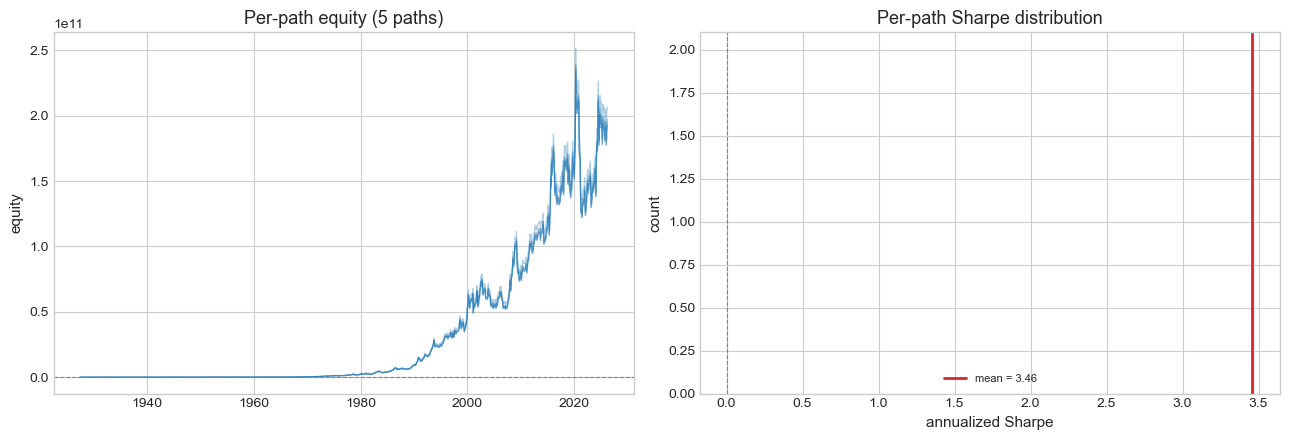

In [85]:
# =============================================================================
# ENGINE CELL 11 — Stage 7: CPCV PMMC metrics (readable)
# Strategy: PMMC only  •  15 splits → 5 stitched paths  •  monthly ann_factor=12
# =============================================================================
if "mp_res_cpcv" not in globals():
    raise RuntimeError("Run ENGINE CELL 10 first")
if "strategies" not in globals():
    raise RuntimeError("Need Cell 8 `strategies` for full-sample reference")

ANN_M = 12

print("What this is:")
print("  • PMMC (capped phi), two-leg + RF, with costs (5+5 bps)")
print("  • CPCV: 5 different 'full timeline' curves built from held-out blocks")
print("  • Compare 'spread across paths' (stability), not CPCV Sharpe vs Cell 8 Sharpe")
print()

# --- reference: one continuous full-sample PMMC (Cell 8) ---
s_ref = strategies["PMMC"].dropna()
eq_ref = (1.0 + s_ref).cumprod()
rep_ref = compute_metrics(s_ref, eq_ref, ann_factor=ANN_M)

# --- each CPCV path ---
per_path = mp_res_cpcv.metrics_per_path()
rows = []
for i, rep in enumerate(per_path):
    rows.append({
        "path": f"path_{i}",
        "ann_return_pct": f"{rep.ann_return * 100:.2f}%",
        "max_drawdown_pct": f"{rep.max_drawdown * 100:.2f}%",
        "sharpe_cpcv": f"{rep.sharpe:.3f}",
        "sortino": f"{rep.sortino:.3f}",
        "hit_rate": f"{rep.hit_rate * 100:.1f}%",
        "months": int(rep.n_obs),
    })
tbl = pd.DataFrame(rows)

print("=== CPCV: each of 5 paths (same strategy, different time-block mixes) ===")
print(tbl.to_string(index=False))

print("\n=== Reference: Cell 8 full-sample PMMC (one continuous run, no CPCV) ===")
print(f"  ann_return     : {rep_ref.ann_return * 100:.2f}%")
print(f"  max_drawdown   : {rep_ref.max_drawdown * 100:.2f}%")
print(f"  sharpe         : {rep_ref.sharpe:.3f}   <- use this vs paper Table 1, not CPCV Sharpe")
print(f"  months         : {rep_ref.n_obs}")

# --- stability across paths ---
ann_pcts = [rep.ann_return * 100 for rep in per_path]
dd_pcts = [rep.max_drawdown * 100 for rep in per_path]
print("\n=== Stability across 5 CPCV paths (lower spread = more robust) ===")
print(f"  ann_return  : {min(ann_pcts):.2f}%  to  {max(ann_pcts):.2f}%   (span {max(ann_pcts)-min(ann_pcts):.2f} pp)")
print(f"  max_drawdown: {min(dd_pcts):.2f}%  to  {max(dd_pcts):.2f}%   (span {max(dd_pcts)-min(dd_pcts):.2f} pp)")
print(f"  vs Cell 8 PMMC ann {rep_ref.ann_return*100:.2f}% — paths within {abs(np.mean(ann_pcts)-rep_ref.ann_return*100):.2f} pp of paper pipeline on average")

agg = mp_res_cpcv.aggregate_metrics()
print("\n=== Across-path summary (mean of 5 paths) ===")
print(f"  ann_return (mean) : {agg['ann_return_mean'] * 100:.2f}%")
print(f"  max_drawdown      : {agg['max_drawdown_mean'] * 100:.2f}%")
print(f"  sharpe (mean)     : {agg['sharpe_mean']:.3f}  (CPCV-stitched series only)")
print(f"  PSR (mean)        : {agg['psr_mean']:.3f}")

print("\n=== Optional: engine charts (path overlay + Sharpe histogram) ===")
_ = mp_res_cpcv.summary(ann_factor=ANN_M)

print("\n[done] Next: ENGINE CELL 12 DSR, CELL 13 registry, CELL 14+ simulation (skill 10).")

In [86]:
# =============================================================================
# ENGINE CELL 12 — Stage 9: DSR (deflated Sharpe Ratio)
# Skill: skills/09-selection.md  •  Depends: CELL 7 res_pmmc, CELL 10–11 mp_res_cpcv
# =============================================================================
for name in ("res_pmmc", "mp_res_cpcv"):
    if name not in globals():
        raise RuntimeError(f"Missing `{name}` — run ENGINE CELLs 7 and 10 first")

from backtest.selection import dsr, expected_max_sr
from backtest.metrics.core import psr, sharpe_var_term

ANN_M = 12

# --- K: distinct strategies you compared in this notebook (NOT CPCV path count) ---
K_ALL = len(strategies.columns)          # WML, VM, PMM, PMMC from Cell 8
K_HEADLINE = 1                           # if PMMC alone is the trial you are claiming

print("What DSR answers:")
print("  'Given K strategy variants tried, is PMMC's Sharpe above expected luck-max?'")
print(f"  CPCV has {mp_res_cpcv.n_paths} paths — that is NOT K (one strategy, many stitches).")
print()

def _dsr_report(label: str, returns, K: int) -> dict:
    r = returns.dropna()
    arr = r.to_numpy(dtype=float)
    T = len(arr)
    sd = arr.std(ddof=1)
    sr_pb = float(arr.mean() / sd) if sd > 1e-12 else float("nan")
    var_term = sharpe_var_term(arr, sr_pb)
    sr_var = var_term / T
    luck_pb = expected_max_sr(K, sr_var)
    luck_ann = luck_pb * np.sqrt(ANN_M)
    sr_ann = sr_pb * np.sqrt(ANN_M)
    return {
        "label": label,
        "K": K,
        "months": T,
        "sharpe_ann": sr_ann,
        "luck_max_ann": luck_ann,
        "psr_vs0": psr(r, sr_star=0.0, ann_factor=ANN_M),
        "dsr": dsr(r, K=K),
    }


# --- headline trial: net two-leg PMMC (engine CELL 7) ---
r_net = res_pmmc.returns.dropna()

print("=== Headline trial: net PMMC (ENGINE CELL 7, costs on) ===")
for K, note in [(K_HEADLINE, "PMMC only — minimum deflation"),
                (K_ALL, f"all {K_ALL} Cell-8 strategies compared this session")]:
    row = _dsr_report("PMMC net", r_net, K)
    sig = "≥95%" if row["dsr"] >= 0.95 else "<95%"
    print(f"\n  K = {K}  ({note})")
    print(f"    realized Sharpe (ann):  {row['sharpe_ann']:.3f}")
    print(f"    luck-max threshold:     {row['luck_max_ann']:.3f}  (E[max SR] across K trials)")
    print(f"    beat luck-max?          {'yes' if row['sharpe_ann'] > row['luck_max_ann'] else 'no'}")
    print(f"    PSR vs 0 (undeflated):  {row['psr_vs0']:.3f}")
    print(f"    DSR (deflated):         {row['dsr']:.3f}   ({sig} vs conventional 0.95)")

# --- CPCV paths: same K, per-path DSR (stability of significance) ---
print("\n=== CPCV PMMC paths (same K as above; paths are not extra trials) ===")
dsr_paths = []
for col in mp_res_cpcv.path_returns.columns:
    d = dsr(mp_res_cpcv.path_returns[col].dropna(), K=K_ALL)
    dsr_paths.append(d)
print(f"  K used: {K_ALL}")
print(f"  DSR per path:  min={min(dsr_paths):.3f}  median={np.median(dsr_paths):.3f}  max={max(dsr_paths):.3f}")

print("\n[done] Next: ENGINE CELL 13 registry, CELL 14+ simulation.")

What DSR answers:
  'Given K strategy variants tried, is PMMC's Sharpe above expected luck-max?'
  CPCV has 5 paths — that is NOT K (one strategy, many stitches).

=== Headline trial: net PMMC (ENGINE CELL 7, costs on) ===

  K = 1  (PMMC only — minimum deflation)
    realized Sharpe (ann):  0.753
    luck-max threshold:     0.000  (E[max SR] across K trials)
    beat luck-max?          yes
    PSR vs 0 (undeflated):  1.000
    DSR (deflated):         1.000   (≥95% vs conventional 0.95)

  K = 4  (all 4 Cell-8 strategies compared this session)
    realized Sharpe (ann):  0.753
    luck-max threshold:     0.114  (E[max SR] across K trials)
    beat luck-max?          yes
    PSR vs 0 (undeflated):  1.000
    DSR (deflated):         1.000   (≥95% vs conventional 0.95)

=== CPCV PMMC paths (same K as above; paths are not extra trials) ===
  K used: 4
  DSR per path:  min=1.000  median=1.000  max=1.000

[done] Next: ENGINE CELL 13 registry, CELL 14+ simulation.


In [87]:
# =============================================================================
# ENGINE CELL 13 — Stage 10: trial registry
# Skill: skills/11-registry.md  •  Depends: CELL 5 engine_results_net, CELL 7
# =============================================================================
for name in ("panel_m", "engine_results_net", "SingleAssetPassThrough"):
    if name not in globals():
        raise RuntimeError(f"Missing `{name}` — run ENGINE CELLs 2 and 5 first")

from backtest.registry import TrialRegistry
import matplotlib.pyplot as plt

FAMILY = "french_equity_net"
STORE = Path("trial_store")
GRAPH = STORE / "causal_graph.png"
STORE.mkdir(parents=True, exist_ok=True)
if not GRAPH.exists():
    fig, ax = plt.subplots(figsize=(4, 2))
    ax.text(0.5, 0.5, "French PMM replication", ha="center", va="center")
    ax.axis("off")
    fig.savefig(GRAPH, bbox_inches="tight")
    plt.close(fig)

reg = TrialRegistry(STORE)
ids = {}
for col in ("WML", "VM", "PMM", "PMMC"):
    ids[col] = reg.log(
        engine_results_net[col],
        SingleAssetPassThrough(col),
        panel_m,
        causal_graph_path=str(GRAPH),
        family=FAMILY,
    )

Kc = reg.k(family=FAMILY, method="count")
Ke = reg.k(family=FAMILY, method="effective", threshold=0.5)
dsr_pmmc = reg.dsr_for(ids["PMMC"], family=FAMILY, method="effective")

print(f"family={FAMILY}  trials={len(reg.list(family=FAMILY, include_exploratory=False))}")
print(f"K={Kc}  K_eff={Ke}  dsr_pmmc={dsr_pmmc:.3f}  ids={ids}")
print(f"store={reg.directory.resolve()}")
print("[done] Next: ENGINE CELL 14 simulation.")

family=french_equity_net  trials=8
K=8  K_eff=1  dsr_pmmc=1.000  ids={'WML': 5, 'VM': 6, 'PMM': 7, 'PMMC': 8}
store=C:\Users\User\backtest_engine\backtest_engine2\trial_store
[done] Next: ENGINE CELL 14 simulation.


In [88]:
import importlib
import backtest.metrics.report as metrics_report
import backtest.metrics as metrics
import backtest.simulation.mc as simulation_mc
importlib.reload(metrics_report)
metrics.compute_metrics = metrics_report.compute_metrics
importlib.reload(simulation_mc)

<module 'backtest.simulation.mc' from 'C:\\Users\\User\\backtest_engine\\backtest\\simulation\\mc.py'>

In [89]:
# =============================================================================
# ENGINE CELL 14 — Stage 8: Monte Carlo (PMMC two-leg, net costs)
# Skill: skills/10-simulation.md
# =============================================================================
for name in ("panel_pmm", "phi1c_s", "phi2c_s", "costs_equity", "start_pmm", "FrenchPartialMomentStrategy"):
    if name not in globals():
        raise RuntimeError(f"Missing `{name}` — run ENGINE CELLs 4 and 7 first")

from backtest.simulation import (
    MonteCarloEngine,
    GaussianGenerator,
    BlockBootstrapGenerator,
    PermutationGenerator,
    GeneratorValidator,
)

ANN_M = 12
N_PATHS = 200
MC_SEED = 0
N_JOBS = -1  # all cores; use 1 for easier debugging

rets_hist = panel_pmm._prices.pct_change().dropna()
real_returns = rets_hist.to_numpy()
mc_dates = pd.DatetimeIndex(rets_hist.index)  # T rows — must match len(dates) for generators
warmup_bars = int(mc_dates.searchsorted(pd.Timestamp(start_pmm)))
liq = liq_equity if "liq_equity" in globals() else None

strat_mc = FrenchPartialMomentStrategy(phi1c_s, phi2c_s, "PMMC")
mc_gens = {
    "gaussian": GaussianGenerator.fit(real_returns),
    "block_bootstrap": BlockBootstrapGenerator.fit(real_returns),
    "permutation": PermutationGenerator(real_returns),
}

validator = GeneratorValidator(real_returns, n_paths=20, seed=MC_SEED)
for name, gen in mc_gens.items():
    vr = validator.validate(gen)
    fail = [m for m, p in vr.passed.items() if not p]
    print(f"{name:18s}  pass={vr.overall_passed}  fail={fail}")

mc_res = MonteCarloEngine(
    strategy=strat_mc,
    generators=mc_gens,
    assets=list(panel_pmm.assets_all),
    dates=mc_dates,
    costs=costs_equity,
    liquidity=liq,
    initial_capital=1_000_000,
    warmup_bars=warmup_bars,
).run(n_paths=N_PATHS, seed=MC_SEED, n_jobs=N_JOBS)

print(f"\nMC: {mc_res.n_paths} paths × {len(mc_gens)} generators  warmup={warmup_bars}")
# ann_return omitted: some synthetic paths lose >100% (CAGR undefined)
mc_table = mc_res.summary(metrics=("sharpe", "max_drawdown", "psr"), quantiles=(0.05, 0.50, 0.95))
perm_med = mc_table.loc["permutation", "sharpe_q50"] if "permutation" in mc_table.index else float("nan")
print(f"permutation median Sharpe: {perm_med:.3f}  (should be ~0; >>0.5 => leak)")
print("[done] Next: ENGINE CELL 15 (OOS engine + multipath + MC summary).")

gaussian            pass=False  fail=['skew_diff', 'kurt_ratio', 'ks_pvalue', 'hill_tail_diff', 'acf_r_lag1_diff', 'acf_abs_r_lag1_diff', 'ljung_box_r2_pvalue', 'corr_frobenius_ratio']
block_bootstrap     pass=True  fail=[]
permutation         pass=False  fail=['acf_r_lag1_diff', 'acf_abs_r_lag1_diff', 'ljung_box_r2_pvalue']

MC: 200 paths × 3 generators  warmup=1
Monte Carlo summary: 200 paths × 3 generators (gaussian, block_bootstrap, permutation)
                 sharpe_mean  sharpe_q05  sharpe_q50  sharpe_q95  max_drawdown_mean  max_drawdown_q05  max_drawdown_q50  max_drawdown_q95  psr_mean  psr_q05  psr_q50  psr_q95
generator                                                                                                                                                                     
gaussian        1.4647       0.6966      1.4615      2.1524      0.9103             0.7679            0.9219            0.9930            0.9866    0.9337   0.9992   1.0000  
block_bootstrap 2.268

In [ ]:
# =============================================================================
# ENGINE CELL 15 — Out-of-sample summary (engine + multipath + Monte Carlo)
#
# Headline: net PMMC two-leg (res_pmmc, ENGINE CELL 7), costs on.
# Also: CPCV MultiPath (mp_res_cpcv, CELL 10) and MC stress (mc_res, CELL 14).
# Depends: CELL 2 PAPER_END, CELL 7 res_pmmc; optional CELL 10, CELL 14.
# =============================================================================

from backtest.metrics.report import compute_metrics

_req = ("res_pmmc", "PAPER_END", "SAMPLE_END")
for name in _req:
    if name not in globals():
        raise RuntimeError(f"Missing `{name}` — run ENGINE CELL 7 (and Cell 2) first")

OOS_START = PAPER_END + 1
_oos_ts = OOS_START.to_timestamp(how="end")


def _slice_oos(returns: pd.Series, equity: pd.Series):
    """First bar on/after OOS_START (month-end timestamps)."""
    r = returns.dropna()
    eq = equity.reindex(r.index).dropna()
    common = r.index.intersection(eq.index)
    r, eq = r.loc[common], eq.loc[common]
    mask = r.index >= _oos_ts
    return r.loc[mask], eq.loc[mask]


def _calendar_year_returns(r: pd.Series) -> pd.Series:
    """Compound return per calendar year (decimal)."""
    if r.empty:
        return pd.Series(dtype=float)
    idx = r.index.to_period("M") if not isinstance(r.index, pd.PeriodIndex) else r.index
    r = r.copy()
    r.index = idx
    return r.groupby(r.index.year).apply(lambda s: (1.0 + s).prod() - 1.0)


def _median_cal_year_return_pct(r: pd.Series) -> float:
    yr = _calendar_year_returns(r)
    return float(yr.median() * 100.0) if len(yr) else float("nan")


def _median_arith_ann_pct(r: pd.Series) -> float:
    """Median of (mean monthly return × 12) within each calendar year, in %."""
    if r.empty:
        return float("nan")
    idx = r.index.to_period("M") if not isinstance(r.index, pd.PeriodIndex) else r.index
    r = r.copy()
    r.index = idx
    vals = [g.mean() * 12 * 100.0 for _, g in r.groupby(r.index.year)]
    return float(np.median(vals)) if vals else float("nan")


def _print_engine_block(label: str, r: pd.Series, eq: pd.Series, costs=None, trades=None):
    n = len(r)
    if n == 0:
        print(f"\n=== {label} ===\n  (no OOS bars after {PAPER_END})")
        return
    rep = compute_metrics(r, eq, costs=costs, trades=trades, ann_factor=12)
    mu_ann = r.mean() * 12
    yr_ret = _calendar_year_returns(r) * 100.0
    print(f"\n=== {label} ===")
    print(f"  window     : {r.index[0].date()} -> {r.index[-1].date()}  ({n} months)")
    print(f"  ann_return : {rep.ann_return:.2%}  (engine CAGR from equity)")
    print(f"  arith_ann  : {mu_ann:.2%}  (mean monthly × 12)")
    print(f"  median_cal_year_ret : {_median_cal_year_return_pct(r):.2f}%  (median calendar-year compound)")
    print(f"  median_arith_ann    : {_median_arith_ann_pct(r):.2f}%  (median of within-year mean×12)")
    print(f"  sharpe     : {rep.sharpe:.4f}  sortino: {rep.sortino:.4f}  max_dd: {rep.max_drawdown:.2%}")
    print(f"  turnover   : {rep.turnover:.4f}  hit_rate: {rep.hit_rate:.2%}")
    if len(yr_ret):
        print("  calendar years (% total):")
        for y, v in yr_ret.items():
            print(f"    {int(y)}  {v:+.2f}%")


# --- 1) Net PMMC engine (headline OOS) ---
r_oos, eq_oos = _slice_oos(res_pmmc.returns, res_pmmc.equity_curve)
c_oos = res_pmmc.costs.reindex(r_oos.index) if getattr(res_pmmc, "costs", None) is not None else None
_print_engine_block(
    "Engine OOS — PMMC two-leg net (res_pmmc)",
    r_oos,
    eq_oos,
    costs=c_oos,
    trades=res_pmmc.trades,
)

# In-sample engine reference (same run)
r_all = res_pmmc.returns.dropna()
eq_all = res_pmmc.equity_curve.reindex(r_all.index).dropna()
mask_is = r_all.index < _oos_ts
if mask_is.any():
    _print_engine_block(
        "Engine in-sample — PMMC (through PAPER_END)",
        r_all.loc[mask_is],
        eq_all.loc[mask_is],
        costs=res_pmmc.costs.reindex(r_all.loc[mask_is].index) if res_pmmc.costs is not None else None,
        trades=res_pmmc.trades,
    )

# --- 2) CPCV MultiPath — OOS slice per path ---
if "mp_res_cpcv" in globals():
    print("\n" + "=" * 72)
    print("CPCV MultiPath (mp_res_cpcv) — OOS metrics per path")
    print("  (stitched CPCV curves; OOS = dates on/after 2019-01)")
    rows = []
    for col in mp_res_cpcv.path_returns.columns:
        pr = mp_res_cpcv.path_returns[col].dropna()
        pe = mp_res_cpcv.path_equity[col].reindex(pr.index).dropna()
        pr_oos = pr.loc[pr.index >= _oos_ts]
        pe_oos = pe.loc[pe.index >= _oos_ts]
        if pr_oos.empty:
            continue
        rep_p = compute_metrics(pr_oos, pe_oos, ann_factor=12)
        rows.append({
            "path": col,
            "n": len(pr_oos),
            "ann_return": rep_p.ann_return,
            "arith_ann": pr_oos.mean() * 12,
            "median_cal_yr": _median_cal_year_return_pct(pr_oos) / 100.0,
            "sharpe": rep_p.sharpe,
            "max_dd": rep_p.max_drawdown,
        })
    if rows:
        cpcv_oos = pd.DataFrame(rows).set_index("path")
        disp = cpcv_oos.copy()
        for c in ("ann_return", "arith_ann", "median_cal_yr", "max_dd"):
            disp[c] = disp[c].map(lambda x: f"{x:.2%}")
        disp["sharpe"] = disp["sharpe"].map(lambda x: f"{x:.4f}")
        print(disp.to_string())
        print("\n  Cross-path OOS (median across 5 CPCV paths):")
        print(f"    ann_return (CAGR)     : {cpcv_oos['ann_return'].median():.2%}")
        print(f"    median_cal_year_ret   : {cpcv_oos['median_cal_yr'].median():.2%}")
        print(f"    sharpe                : {cpcv_oos['sharpe'].median():.4f}")
        print(f"    max_drawdown          : {cpcv_oos['max_dd'].median():.2%}")
    else:
        print("  (no OOS bars on CPCV paths)")
    print("\n  Full-sample CPCV aggregate (all dates, for stability — not OOS):")
    agg = mp_res_cpcv.aggregate_metrics()
    for k in ("ann_return_mean", "sharpe_mean", "max_drawdown_mean"):
        if k in agg:
            v = agg[k]
            print(f"    {k}: {v:.2%}" if "return" in k or "drawdown" in k else f"    {k}: {v:.4f}")
else:
    print("\n[skip] mp_res_cpcv — run ENGINE CELL 10 first")

# --- 3) Monte Carlo multipath stress (full timeline, not OOS calendar) ---
if "mc_res" in globals():
    print("\n" + "=" * 72)
    print("Monte Carlo (mc_res) — distribution across synthetic paths")
    print("  Note: stress-test on full fitted history + warmup; not post-2018 OOS only.")
    mc_metrics = ("sharpe", "max_drawdown", "psr")
    mc_table = mc_res.summary(metrics=mc_metrics, quantiles=(0.05, 0.50, 0.95))
    # Median calendar-year return across MC paths (each path full series)
    print("\n  Median calendar-year return across MC paths (per generator, % compound):")
    for gen, rets_df in mc_res.path_returns.items():
        med_yrs = []
        for col in rets_df.columns:
            yr = _calendar_year_returns(rets_df[col].dropna())
            if len(yr):
                med_yrs.append(yr.median() * 100.0)
        med_path = float(np.median(med_yrs)) if med_yrs else float("nan")
        print(f"    {gen:18s}  median of per-path median cal-year ret: {med_path:.2f}%")
    if "permutation" in mc_table.index:
        print(f"\n  permutation Sharpe q50: {mc_table.loc['permutation', 'sharpe_q50']:.3f}  (null ~0)")
else:
    print("\n[skip] mc_res — run ENGINE CELL 14 first")

print("\n[done] ENGINE CELL 15 — OOS engine + multipath + MC summary.")
